This notebook serves as a place containing my work for homework 4

Hitting 'Run all' on the code should work as expected.

**Note of the structure:** I have split the notebook into 3 sections - 1 sections per model. In each section, it will make each model and get organize its predictions for top 10 and bottom 10, get the out of sample performance for it, then get the repeatability for it. At the very bottom, all of the questions will be answered.

# **Question 1.)**

### Build three models for FBS team evaluation: an SRS model of score differential only, an opponent adjusted game control model, and an opponent adjusted average win probability (awp) model.  Give the top 10 and botton 10 teams for each season from 2021 to 2025.

In [248]:
# import neccesary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from IPython.display import display, Markdown
import sportsdataverse as sdv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.metrics import r2_score

---

# **SRS model (score differential only)**

In [249]:
# define the season range
seasons = range(2021, 2026)
games_list = []

for season in seasons:
    url = f"https://raw.githubusercontent.com/sportsdataverse/cfbfastR-data/main/schedules/csv/cfb_schedules_{season}.csv"
    df_season = pd.read_csv(url)
    games_list.append(df_season)

raw_games = pd.concat(games_list, ignore_index=True)

# Clean and filter for completed games with valid scores
games_clean = raw_games[
    (raw_games['completed'] == True) &
    (raw_games['home_points'].notna()) &
    (raw_games['away_division']=='fbs') &
    (raw_games['away_points'].notna()) &
    (raw_games['season_type'].isin(['regular']))
][['season', 'week', 'home_team', 'away_team', 'home_points', 'away_points']].sort_values(['season', 'week']).reset_index(drop=True)

In [250]:
# Make an SRS function
def calc_srs_scratch(df):
    # Reset index to guarantee alignment with 0..n_games range
    df = df.reset_index(drop=True)
    
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)
    
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    
    for i, row in df.iterrows():
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0
        
    margin = df['home_points'] - df['away_points']
    X = sm.add_constant(X)
    fit = sm.OLS(margin, X).fit()
    srs_vec = fit.params.fillna(0)
    srs_centered = srs_vec - srs_vec.mean()
    
    return pd.DataFrame({
        'team': srs_centered.index,
        'SRS': np.round(srs_centered.values, 2)
    })

In [251]:
# calculate SRS for each season
def compute_season_ratings(season_df):
    year = season_df['season'].iloc[0]
    srs_df = calc_srs_scratch(season_df)
    srs_df['season'] = year
    return srs_df.sort_values(by='SRS', ascending=False).reset_index(drop=True)

# Execute loop across split season datasets
ratings_list = []
for year, season_df in games_clean.groupby('season'):
    ratings_list.append(compute_season_ratings(season_df))

ratings_by_season = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

In [252]:
# List top 10 teams by SRS for each season
for yr in sorted(ratings_by_season['season'].unique()):
    top_rankings = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='SRS', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top_rankings['Rank'] = top_rankings.index + 1
    
    top_rankings = top_rankings[[
        'Rank', 'team', 'SRS'
    ]].rename(columns={
        'team': 'Team',
        'SRS': 'SRS Rating',
    })
    
    display(Markdown(f"### Top 10 Teams by SRS for Season: {yr}"))
    display(Markdown(top_rankings.to_markdown(index=False)))

### Top 10 Teams by SRS for Season: 2021

|   Rank | Team           |   SRS Rating |
|-------:|:---------------|-------------:|
|      1 | Georgia        |        35.58 |
|      2 | Alabama        |        29.23 |
|      3 | Ohio State     |        28.62 |
|      4 | Michigan       |        25.77 |
|      5 | Notre Dame     |        21.67 |
|      6 | Oklahoma State |        19.92 |
|      7 | Utah           |        19.82 |
|      8 | Cincinnati     |        19.35 |
|      9 | Iowa State     |        17.16 |
|     10 | Wisconsin      |        16.57 |

### Top 10 Teams by SRS for Season: 2022

|   Rank | Team         |   SRS Rating |
|-------:|:-------------|-------------:|
|      1 | Georgia      |        33.86 |
|      2 | Tennessee    |        30.29 |
|      3 | Alabama      |        29.76 |
|      4 | Ohio State   |        29.22 |
|      5 | Michigan     |        28.03 |
|      6 | Texas        |        25.14 |
|      7 | Kansas State |        24.52 |
|      8 | TCU          |        23.58 |
|      9 | Penn State   |        22.47 |
|     10 | Utah         |        20.41 |

### Top 10 Teams by SRS for Season: 2023

|   Rank | Team          |   SRS Rating |
|-------:|:--------------|-------------:|
|      1 | Michigan      |        30.28 |
|      2 | Oregon        |        29.97 |
|      3 | Ohio State    |        28.46 |
|      4 | Penn State    |        27.53 |
|      5 | Oklahoma      |        25.83 |
|      6 | Texas         |        25.66 |
|      7 | Georgia       |        24.26 |
|      8 | Notre Dame    |        23.39 |
|      9 | Kansas State  |        22.73 |
|     10 | Florida State |        22.38 |

### Top 10 Teams by SRS for Season: 2024

|   Rank | Team           |   SRS Rating |
|-------:|:---------------|-------------:|
|      1 | Notre Dame     |        27.95 |
|      2 | Texas          |        27.33 |
|      3 | Ohio State     |        27.14 |
|      4 | Alabama        |        25.71 |
|      5 | Ole Miss       |        24.5  |
|      6 | Indiana        |        23.38 |
|      7 | Georgia        |        22.95 |
|      8 | Tennessee      |        22.64 |
|      9 | Oregon         |        22.63 |
|     10 | South Carolina |        21.74 |

### Top 10 Teams by SRS for Season: 2025

|   Rank | Team       |   SRS Rating |
|-------:|:-----------|-------------:|
|      1 | Indiana    |        37.28 |
|      2 | Ohio State |        32.5  |
|      3 | Texas Tech |        31.9  |
|      4 | Oregon     |        30.13 |
|      5 | Notre Dame |        29.44 |
|      6 | Utah       |        25.56 |
|      7 | Miami      |        24.63 |
|      8 | Georgia    |        22.46 |
|      9 | USC        |        21.54 |
|     10 | Iowa       |        21.02 |

In [253]:
# List bottom 10 teams by SRS for each season
for yr in sorted(ratings_by_season['season'].unique()):
    bottom_rankings = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='SRS', ascending=True)
        .head(10)
        .reset_index(drop=True)
    )
    bottom_rankings['Rank'] = bottom_rankings.index + 1
    
    bottom_rankings = bottom_rankings[[
        'Rank', 'team', 'SRS'
    ]].rename(columns={
        'team': 'Team',
        'SRS': 'SRS Rating',
    })
    
    display(Markdown(f"### Bottom 10 Teams by SRS for Season: {yr}"))
    display(Markdown(bottom_rankings.to_markdown(index=False)))

### Bottom 10 Teams by SRS for Season: 2021

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Florida International |       -33.09 |
|      2 | Jacksonville State    |       -32.51 |
|      3 | Massachusetts         |       -30.72 |
|      4 | Akron                 |       -29.86 |
|      5 | Temple                |       -28.79 |
|      6 | UConn                 |       -28.02 |
|      7 | Southern Miss         |       -22.21 |
|      8 | New Mexico State      |       -21.6  |
|      9 | Arkansas State        |       -21.33 |
|     10 | Duke                  |       -20.71 |

### Bottom 10 Teams by SRS for Season: 2022

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Florida International |       -32.56 |
|      2 | Massachusetts         |       -29.01 |
|      3 | New Mexico            |       -24.59 |
|      4 | Charlotte             |       -23.77 |
|      5 | Hawai'i               |       -23.42 |
|      6 | Louisiana Tech        |       -20.61 |
|      7 | New Mexico State      |       -20.21 |
|      8 | Nevada                |       -19.8  |
|      9 | Colorado              |       -19.49 |
|     10 | Akron                 |       -18.54 |

### Bottom 10 Teams by SRS for Season: 2023

|   Rank | Team                  |   SRS Rating |
|-------:|:----------------------|-------------:|
|      1 | Kent State            |       -32.03 |
|      2 | Temple                |       -25.42 |
|      3 | Akron                 |       -24.01 |
|      4 | UL Monroe             |       -21.87 |
|      5 | Florida International |       -20.77 |
|      6 | Massachusetts         |       -20.18 |
|      7 | Eastern Michigan      |       -19.15 |
|      8 | Charlotte             |       -18.8  |
|      9 | Nevada                |       -18.68 |
|     10 | Southern Miss         |       -17.91 |

### Bottom 10 Teams by SRS for Season: 2024

|   Rank | Team             |   SRS Rating |
|-------:|:-----------------|-------------:|
|      1 | Kent State       |       -34.84 |
|      2 | Tulsa            |       -32.78 |
|      3 | Southern Miss    |       -29    |
|      4 | Middle Tennessee |       -26.85 |
|      5 | New Mexico State |       -26.72 |
|      6 | Kennesaw State   |       -26.32 |
|      7 | UTEP             |       -23.2  |
|      8 | Temple           |       -21.88 |
|      9 | Ball State       |       -21.04 |
|     10 | Central Michigan |       -20.98 |

### Bottom 10 Teams by SRS for Season: 2025

|   Rank | Team          |   SRS Rating |
|-------:|:--------------|-------------:|
|      1 | Massachusetts |       -37.85 |
|      2 | Sam Houston   |       -28.88 |
|      3 | UL Monroe     |       -25.6  |
|      4 | Charlotte     |       -24.65 |
|      5 | Georgia State |       -23.24 |
|      6 | Akron         |       -22.99 |
|      7 | Ball State    |       -22.58 |
|      8 | UTEP          |       -20.7  |
|      9 | Kent State    |       -20.29 |
|     10 | Rice          |       -19.27 |

## Test the out of sample performance of the SRS model:

For the out of sample prediction we will be splitting it by half-seasons. Models trained on first half of the season, tested on the last half.

In [254]:
def calc_srs_model(df):
    """Fit the SRS OLS model and return the fitted statsmodels object (not just ratings)."""
    df = df.reset_index(drop=True)
    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)
    
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    for i, row in df.iterrows():
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0
        
    margin = df['home_points'] - df['away_points']
    X = sm.add_constant(X)
    fit = sm.OLS(margin, X).fit()
    
    return fit, X.columns  # return fitted model + column order used

def split_season_half(season_df):
    """Split one season's games into first-half and second-half by week."""
    season_df = season_df.sort_values('week')
    midpoint_week = season_df['week'].median()
    
    first_half = season_df[season_df['week'] <= midpoint_week]
    second_half = season_df[season_df['week'] > midpoint_week]
    
    return first_half, second_half

def build_design_matrix(games_df, team_columns):
    """Build a design matrix for a new set of games, matching the training columns exactly."""
    games_df = games_df.reset_index(drop=True)
    n_games = len(games_df)
    
    X_new = pd.DataFrame(0.0, index=range(n_games), columns=team_columns)
    X_new['const'] = 1.0
    
    for i, row in games_df.iterrows():
        if row['home_team'] in X_new.columns:
            X_new.loc[i, row['home_team']] = 1.0
        if row['away_team'] in X_new.columns:
            X_new.loc[i, row['away_team']] = -1.0
    
    return X_new[team_columns]  # enforce same column order as training


# Loop across seasons
results_list = []

for year, season_df in games_clean.groupby('season'):
    first_half, second_half = split_season_half(season_df)
    
    # Fit SRS model on first-half games only
    fit, team_columns = calc_srs_model(first_half)

    for year, season_df in games_clean.groupby('season'):
        first_half, second_half = split_season_half(season_df)
        second_half = second_half.reset_index(drop=True)  # <-- add this
        
        fit, team_columns = calc_srs_model(first_half)
        X_holdout = build_design_matrix(second_half, team_columns)
        
        second_half['predicted_margin'] = fit.predict(X_holdout)
        second_half['actual_margin'] = second_half['home_points'] - second_half['away_points']
        second_half['season'] = year
        results_list.append(second_half)
    
    # Build matching design matrix for second-half (holdout) games
    X_holdout = build_design_matrix(second_half, team_columns)
    
    # Predict margins for second-half games using first-half-fitted model
    second_half = second_half.copy()
    second_half['predicted_margin'] = fit.predict(X_holdout)
    second_half['actual_margin'] = second_half['home_points'] - second_half['away_points']
    second_half['season'] = year
    
    results_list.append(second_half)

holdout_results = pd.concat(results_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\622164972.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\622164972.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\622164972.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\622164972.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\622164972.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely

In [255]:
holdout_results

,season,week,home_team,away_team,home_points,away_points,predicted_margin,actual_margin
0,2021,8,Central Michigan,Northern Illinois,38.0,39.0,-7.595077,-1.0
1,2021,8,Navy,Cincinnati,20.0,27.0,-40.365263,-7.0
2,2021,8,Bowling Green,Eastern Michigan,24.0,55.0,-6.826883,-31.0
3,2021,8,Texas Tech,Kansas State,24.0,25.0,-12.115073,-1.0
4,2021,8,Kansas,Oklahoma,23.0,35.0,-36.810663,-12.0
...,...,...,...,...,...,...,...,...
10720,2025,15,Jacksonville State,Kennesaw State,15.0,19.0,-8.343911,-4.0
10721,2025,15,Boise State,UNLV,38.0,21.0,17.251232,17.0
10722,2025,15,Texas Tech,BYU,34.0,7.0,14.194022,27.0
10723,2025,15,James Madison,Troy,31.0,14.0,13.232191,17.0


In [256]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Basic regression accuracy: how close are predicted margins to actual margins?
mae = mean_absolute_error(holdout_results['actual_margin'], holdout_results['predicted_margin'])
rmse = np.sqrt(mean_squared_error(holdout_results['actual_margin'], holdout_results['predicted_margin']))
corr = holdout_results['predicted_margin'].corr(holdout_results['actual_margin'])

print(f"Out-of-sample MAE: {mae:.2f}")
print(f"Out-of-sample RMSE: {rmse:.2f}")
print(f"Correlation (predicted vs actual margin): {corr:.3f}")

# If you also want win/loss accuracy (not just margin accuracy)
holdout_results['predicted_win'] = (holdout_results['predicted_margin'] > 0).astype(int)
holdout_results['actual_win'] = (holdout_results['actual_margin'] > 0).astype(int)

accuracy = (holdout_results['predicted_win'] == holdout_results['actual_win']).mean()
print(f"Out-of-sample win/loss accuracy: {accuracy:.3f}")

Out-of-sample MAE: 13.67
Out-of-sample RMSE: 17.05
Correlation (predicted vs actual margin): 0.567
Out-of-sample win/loss accuracy: 0.692


Quite bad out of sample performance, however this is all within a season and many different things occur throughout a season that this model does not account for.

## Repeatability for SRS model

In [257]:
import numpy as np
import pandas as pd
from scipy import stats
from great_tables import GT
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes split_season_half() is already defined (chunk 1)

def calc_rating_scratch(df):
    """Fit OLS margin model on team dummies; return centered team ratings (renamed from SRS)."""
    df = df.reset_index(drop=True)

    teams = np.unique(np.concatenate([df['home_team'].unique(), df['away_team'].unique()]))
    n_games = len(df)

    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)

    for i, row in df.iterrows():
        X.loc[i, row['home_team']] = 1.0
        X.loc[i, row['away_team']] = -1.0

    margin = df['home_points'] - df['away_points']
    X = sm.add_constant(X)
    fit = sm.OLS(margin, X).fit()
    rating_vec = fit.params.fillna(0)
    rating_centered = rating_vec - rating_vec.mean()

    return pd.DataFrame({
        'team': rating_centered.index,
        'Rating': np.round(rating_centered.values, 2)
    })


predictor_funcs = {
    'Rating': calc_rating_scratch,
}


def build_predictor_panel(df, funcs):
    """Apply each predictor function to df and combine into one team-indexed wide frame."""
    panels = []
    for name, func in funcs.items():
        result = func(df).set_index('team')
        predictor_col = [c for c in result.columns if c != 'season'][0]
        result = result[[predictor_col]].rename(columns={predictor_col: name})
        panels.append(result)
    combined = pd.concat(panels, axis=1)
    return combined.reset_index()


season_tables = {}     # season -> correlation_results DataFrame (rows = predictors)
season_gt_tables = {}  # season -> GT object
season_panels = {}     # season -> merged H1/H2 team panel

for year, season_df in games_clean.groupby('season'):
    first_half, second_half = split_season_half(season_df)

    h1_panel = build_predictor_panel(first_half, predictor_funcs)
    h2_panel = build_predictor_panel(second_half, predictor_funcs)

    merged = h1_panel.merge(h2_panel, on='team', how='inner', suffixes=('_H1', '_H2'))
    season_panels[year] = merged

    corr_rows = []
    for name in predictor_funcs.keys():
        col_h1, col_h2 = f"{name}_H1", f"{name}_H2"
        valid = merged[[col_h1, col_h2]].dropna()

        if len(valid) < 3:
            r, p_val = np.nan, np.nan
        else:
            r, p_val = stats.pearsonr(valid[col_h1], valid[col_h2])

        corr_rows.append({
            'predictor': name,
            'n_teams': len(valid),
            'r': r,
            'p_value': p_val,
            'r_squared': r ** 2 if pd.notnull(r) else np.nan
        })

    season_results = pd.DataFrame(corr_rows).sort_values(by='r', ascending=False)
    season_tables[year] = season_results

    gt_table = (
        GT(season_results)
        .tab_header(
            title=f"{year} Split-Half Predictor Reliability",
            subtitle="Pearson Correlation (r) between First-Half and Second-Half fitted Rating"
        )
        .cols_label(
            predictor="Predictor",
            n_teams="N Teams",
            r="Pearson r",
            p_value="p-value",
            r_squared="R²"
        )
        .fmt_number(columns=["r", "p_value", "r_squared"], decimals=3)
    )
    season_gt_tables[year] = gt_table

# Display each season's table
for year, gt_table in season_gt_tables.items():
    display(gt_table)



C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3912895654.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3912895654.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3912895654.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3912895654.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3912895654.py:25: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Rating      131  0.649837  4.559800e-17   0.422288, _body=<great_tables._gt_data.Body object at 0x0000021729D6CE60>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002173E263AD0>, _spanners=Spanners([]), _heading=Heading(title='2021 Split-Half Predictor Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half fitted Rating', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172B0EDFD0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172B0EE180>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172B0EF5C0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x00000217295AC0B0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='tab

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Rating      132  0.562975  2.121266e-12   0.316941, _body=<great_tables._gt_data.Body object at 0x000002172B4DE3C0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000217295A4350>, _spanners=Spanners([]), _heading=Heading(title='2022 Split-Half Predictor Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half fitted Rating', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172B4DD0A0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172B4DD340>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172B4DEFC0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000021729D65490>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='tab

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Rating      134  0.610175  5.024350e-15   0.372314, _body=<great_tables._gt_data.Body object at 0x0000021787C3C140>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000021729D665A0>, _spanners=Spanners([]), _heading=Heading(title='2023 Split-Half Predictor Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half fitted Rating', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000021729D59FD0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000021729D5AD20>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000021729D59610>, _formats=[<great_tables._gt_data.FormatInfo object at 0x00000217284F4B90>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='tab

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Rating      135  0.690991  1.781281e-20   0.477469, _body=<great_tables._gt_data.Body object at 0x0000021729D5DDF0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000021729D6C680>, _spanners=Spanners([]), _heading=Heading(title='2024 Split-Half Predictor Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half fitted Rating', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000021729D5D8E0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000021729D5C3E0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000021729D5E6C0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000021729D5F920>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='tab

GT(_tbl_data=  predictor  n_teams        r       p_value  r_squared
0    Rating      137  0.62496  3.291536e-16   0.390575, _body=<great_tables._gt_data.Body object at 0x000002173CFF8290>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000217295A6360>, _spanners=Spanners([]), _heading=Heading(title='2025 Split-Half Predictor Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half fitted Rating', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002173CB7EF90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172B064B30>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x00000217501A5850>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002173CFFBEF0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table

Seems like there is a solid level of consistency for SRS amongst first and second half portions of seasons.

---

# **Opponent-adjusted game control model**

Get the data.

In [258]:
# Import college football data from 2021 to 2025
cfb_data = sdv.cfb.load_cfb_pbp([2021, 2022, 2023, 2024, 2025], return_as_pandas=False)

# Convert the polar files to pandas dataframes
cfb_data = cfb_data.to_pandas(use_pyarrow_extension_array=False)

In [259]:
# Create a list of all FBS schools
fbs_teams = ["Boston College", "California", "Clemson", "Duke", "Florida State",
    "Georgia Tech", "Louisville", "Miami", "NC State", "North Carolina",
    "Pittsburgh", "SMU", "Stanford", "Syracuse", "Virginia",
    "Virginia Tech", "Wake Forest", "Illinois", "Indiana", "Iowa", "Maryland", "Michigan",
    "Michigan State", "Minnesota", "Nebraska", "Northwestern", "Ohio State",
    "Oregon", "Penn State", "Purdue", "Rutgers", "UCLA",
    "USC", "Washington", "Wisconsin", "Arizona", "Arizona State", "Baylor", "BYU", "Cincinnati",
    "Colorado", "Houston", "Iowa State", "Kansas", "Kansas State",
    "Oklahoma State", "TCU", "Texas Tech", "UCF", "Utah",
    "West Virginia", "Alabama", "Arkansas", "Auburn", "Florida", "Georgia",
    "Kentucky", "LSU", "Mississippi State", "Missouri", "Oklahoma",
    "Ole Miss", "South Carolina", "Tennessee", "Texas", "Texas A&M",
    "Vanderbilt", "Army", "Charlotte", "East Carolina", "Florida Atlantic", "Memphis",
    "Navy", "North Texas", "Rice", "Temple", "Tulane",
    "Tulsa", "UAB", "South Florida", "UTSA", "Boise State", "Colorado State", "Fresno State",
    "Oregon State", "San Diego State", "Texas State", "Utah State", "Washington State",
    "Air Force", "Hawai'i", "Nevada", "New Mexico", "North Dakota State",
    "Northern Illinois", "San José State", "UNLV", "UTEP", "Wyoming",
    "Akron", "Ball State", "Bowling Green", "Buffalo", "Central Michigan",
    "Eastern Michigan", "Kent State", "Miami (OH)", "Ohio", "Sacramento State",
    "Toledo", "Massachusetts", "Western Michigan",
    "Delaware", "Florida International", "Jacksonville State", "Kennesaw State", "Liberty",
    "Middle Tennessee", "Missouri State", "New Mexico State", "Sam Houston", "Western Kentucky",
    "Appalachian State", "Arkansas State", "Coastal Carolina", "Georgia Southern", "Georgia State",
    "James Madison", "Louisiana", "Louisiana Tech", "Marshall", "Old Dominion",
    "South Alabama", "Southern Miss", "Troy", "UL Monroe", "Notre Dame", "UConn"
]

# Now, let's filter the data so that it only keeps fbs vs fbs games
# and it only keeps the regular season games and plays that we care about on offense.
cfb_data = cfb_data[(cfb_data['homeTeamName'].isin(fbs_teams)) & (cfb_data['awayTeamName'].isin(fbs_teams))
].copy()

In [260]:
# Create a dictionary to map the values
school_mapping = {
    "Boston College Eagles": "Boston College",
    "California Golden Bears": "California",
    "Clemson Tigers": "Clemson",
    "Duke Blue Devils": "Duke",
    "Florida State Seminoles": "Florida State",
    "Georgia Tech Yellow Jackets": "Georgia Tech",
    "Louisville Cardinals": "Louisville",
    "Miami Hurricanes": "Miami",
    "NC State Wolfpack": "NC State",
    "North Carolina Tar Heels": "North Carolina",
    "Pittsburgh Panthers": "Pittsburgh",
    "SMU Mustangs": "SMU",
    "Stanford Cardinal": "Stanford",
    "Syracuse Orange": "Syracuse",
    "Virginia Cavaliers": "Virginia",
    "Virginia Tech Hokies": "Virginia Tech",
    "Wake Forest Demon Deacons": "Wake Forest",
    "Illinois Fighting Illini": "Illinois",
    "Indiana Hoosiers": "Indiana",
    "Iowa Hawkeyes": "Iowa",
    "Maryland Terrapins": "Maryland",
    "Michigan Wolverines": "Michigan",
    "Michigan State Spartans": "Michigan State",
    "Minnesota Golden Gophers": "Minnesota",
    "Nebraska Cornhuskers": "Nebraska",
    "Northwestern Wildcats": "Northwestern",
    "Ohio State Buckeyes": "Ohio State",
    "Oregon Ducks": "Oregon",
    "Penn State Nittany Lions": "Penn State",
    "Purdue Boilermakers": "Purdue",
    "Rutgers Scarlet Knights": "Rutgers",
    "UCLA Bruins": "UCLA",
    "USC Trojans": "USC",
    "Washington Huskies": "Washington",
    "Wisconsin Badgers": "Wisconsin",
    "Arizona Wildcats": "Arizona",
    "Arizona State Sun Devils": "Arizona State",
    "Baylor Bears": "Baylor",
    "BYU Cougars": "BYU",
    "Cincinnati Bearcats": "Cincinnati",
    "Colorado Buffaloes": "Colorado",
    "Houston Cougars": "Houston",
    "Iowa State Cyclones": "Iowa State",
    "Kansas Jayhawks": "Kansas",
    "Kansas State Wildcats": "Kansas State",
    "Oklahoma State Cowboys": "Oklahoma State",
    "TCU Horned Frogs": "TCU",
    "Texas Tech Red Raiders": "Texas Tech",
    "UCF Knights": "UCF",
    "Utah Utes": "Utah",
    "West Virginia Mountaineers": "West Virginia",
    "Alabama Crimson Tide": "Alabama",
    "Arkansas Razorbacks": "Arkansas",
    "Auburn Tigers": "Auburn",
    "Florida Gators": "Florida",
    "Georgia Bulldogs": "Georgia",
    "Kentucky Wildcats": "Kentucky",
    "LSU Tigers": "LSU",
    "Mississippi State Bulldogs": "Mississippi State",
    "Missouri Tigers": "Missouri",
    "Oklahoma Sooners": "Oklahoma",
    "Ole Miss Rebels": "Ole Miss",
    "South Carolina Gamecocks": "South Carolina",
    "Tennessee Volunteers": "Tennessee",
    "Texas Longhorns": "Texas",
    "Texas A&M Aggies": "Texas A&M",
    "Vanderbilt Commodores": "Vanderbilt",
    "Army Black Knights": "Army",
    "Charlotte 49ers": "Charlotte",
    "East Carolina Pirates": "East Carolina",
    "Florida Atlantic Owls": "Florida Atlantic",
    "Memphis Tigers": "Memphis",
    "Navy Midshipmen": "Navy",
    "North Texas Mean Green": "North Texas",
    "Rice Owls": "Rice",
    "Temple Owls": "Temple",
    "Tulane Green Wave": "Tulane",
    "Tulsa Golden Hurricane": "Tulsa",
    "UAB Blazers": "UAB",
    "South Florida Bulls": "South Florida",
    "UTSA Roadrunners": "UTSA",
    "Boise State Broncos": "Boise State",
    "Colorado State Rams": "Colorado State",
    "Fresno State Bulldogs": "Fresno State",
    "Oregon State Beavers": "Oregon State",
    "San Diego State Aztecs": "San Diego State",
    "Texas State Bobcats": "Texas State",
    "Utah State Aggies": "Utah State",
    "Washington State Cougars": "Washington State",
    "Air Force Falcons": "Air Force",
    "Hawai'i Rainbow Warriors": "Hawai'i",
    "Nevada Wolf Pack": "Nevada",
    "New Mexico Lobos": "New Mexico",
    "North Dakota State Bison": "North Dakota State",
    "Northern Illinois Huskies": "Northern Illinois",
    "San José State Spartans": "San José State",
    "UNLV Rebels": "UNLV",
    "UTEP Miners": "UTEP",
    "Wyoming Cowboys": "Wyoming",
    "Akron Zips": "Akron",
    "Ball State Cardinals": "Ball State",
    "Bowling Green Falcons": "Bowling Green",
    "Buffalo Bulls": "Buffalo",
    "Central Michigan Chippewas": "Central Michigan",
    "Eastern Michigan Eagles": "Eastern Michigan",
    "Kent State Golden Flashes": "Kent State",
    "Miami (OH) RedHawks": "Miami (OH)",
    "Ohio Bobcats": "Ohio",
    "Sacramento State Hornets": "Sacramento State",
    "Toledo Rockets": "Toledo",
    "Massachusetts Minutemen": "Massachusetts",
    "Western Michigan Broncos": "Western Michigan",
    "Delaware Blue Hens": "Delaware",
    "Florida International Panthers": "Florida International",
    "Jacksonville State Gamecocks": "Jacksonville State",
    "Kennesaw State Owls": "Kennesaw State",
    "Liberty Flames": "Liberty",
    "Middle Tennessee Blue Raiders": "Middle Tennessee",
    "Missouri State Bears": "Missouri State",
    "New Mexico State Aggies": "New Mexico State",
    "Sam Houston Bearkats": "Sam Houston",
    "Western Kentucky Hilltoppers": "Western Kentucky",
    "Appalachian State Mountaineers": "Appalachian State",
    "Arkansas State Red Wolves": "Arkansas State",
    "Coastal Carolina Chanticleers": "Coastal Carolina",
    "Georgia Southern Eagles": "Georgia Southern",
    "Georgia State Panthers": "Georgia State",
    "James Madison Dukes": "James Madison",
    "Louisiana Ragin' Cajuns": "Louisiana",
    "Louisiana Tech Bulldogs": "Louisiana Tech",
    "Marshall Thundering Herd": "Marshall",
    "Old Dominion Monarchs": "Old Dominion",
    "South Alabama Jaguars": "South Alabama",
    "Southern Miss Golden Eagles": "Southern Miss",
    "Troy Trojans": "Troy",
    "UL Monroe Warhawks": "UL Monroe",
    "Notre Dame Fighting Irish": "Notre Dame",
    "UConn Huskies": "UConn",
}

# Map the values to replace the values in pos_team and def_pos_team
cfb_data['pos_team'] = cfb_data['pos_team'].map(school_mapping)
cfb_data['def_pos_team'] = cfb_data['def_pos_team'].map(school_mapping)

# Check that it worked as expected
cfb_data['pos_team'].value_counts()

pos_team
Texas Tech            5739
Texas                 5701
Ole Miss              5677
USC                   5667
UTSA                  5624
                      ... 
Kennesaw State        2336
Missouri State        1516
Delaware              1335
Sacramento State       474
North Dakota State     251
Name: count, Length: 138, dtype: int64

In [261]:
# make a game seconds remaining stat for the pbp data
cfb_data['game_seconds_remaining'] = np.where(cfb_data['half'] == 1, cfb_data['end.TimeSecsRem'].astype(float) + 1800, cfb_data['end.TimeSecsRem'].astype(float))

In [262]:
# Filter completed plays and compute duration between play events
pbp_clean = cfb_data[
    (cfb_data['seasonType'] == 2) &
    (cfb_data['game_seconds_remaining'].notna()) &
    (cfb_data['homeScore'].notna()) &
    (cfb_data['awayScore'].notna()) &
    (cfb_data['homeTeamName'].notna()) &
    (cfb_data['awayTeamName'].notna())
].copy()

pbp_clean = pbp_clean.sort_values(['season', 'game_id', 'game_seconds_remaining'], ascending=[True, True, False])

pbp_clean['home_lead'] = pbp_clean['homeScore'] - pbp_clean['awayScore']

# Elapsed seconds from previous play state
prev_seconds = pbp_clean.groupby('game_id')['game_seconds_remaining'].shift(1).fillna(3600)
pbp_clean['play_duration'] = prev_seconds - pbp_clean['game_seconds_remaining']
pbp_clean['play_duration'] = np.maximum(0, pbp_clean['play_duration'])

In [263]:
# Calculate time-weighted score differential per game for home and away teams
def calc_game_gc(group):
    total_time = group['play_duration'].sum()
    denom = total_time if total_time > 0 else 1.0
    home_gc = (group['home_lead'] * group['play_duration']).sum() / denom
    return pd.Series({
        'total_time': total_time,
        'home_gc': home_gc,
        'away_gc': -home_gc
    })

game_control_by_game = pbp_clean.groupby(['season', 'week', 'game_id', 'homeTeamName', 'awayTeamName'], group_keys=False).apply(calc_game_gc).reset_index()

# Reshape data into long team-game format
home_df = game_control_by_game[['season', 'game_id', 'homeTeamName', 'home_gc', 'week']].rename(columns={'homeTeamName': 'team', 'home_gc': 'game_control'})
away_df = game_control_by_game[['season', 'game_id', 'awayTeamName', 'away_gc', 'week']].rename(columns={'awayTeamName': 'team', 'away_gc': 'game_control'})

team_games = pd.concat([home_df, away_df], ignore_index=True)

# Aggregate across each season
season_game_control = team_games.groupby(['season', 'team']).agg(
    games_played=('game_control', 'count'),
    avg_game_control=('game_control', lambda x: np.round(x.mean(), 2))
).reset_index().sort_values(['season', 'avg_game_control'], ascending=[True, False])

In [264]:
def calc_adj_gc_scratch(df):
    teams = np.unique(np.concatenate([df['homeTeamName'].unique(), df['awayTeamName'].unique()]))
    n_games = len(df)
    season = df['season'].iloc[0]
    
    # Construct design matrix: Home (+1), Away (-1)
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    
    for i, (_, row) in enumerate(df.iterrows()):
        X.loc[i, row['homeTeamName']] = 1.0
        X.loc[i, row['awayTeamName']] = -1.0
        
    margin = df['home_gc'].values
    
    # Add intercept column (column of ones)
    X_design = sm.add_constant(X)
    #X_design=X   
    # Fit OLS model
    fit = sm.OLS(margin, X_design).fit()
    srs_vec = fit.params.fillna(0)
    srs_vec = srs_vec.rename(index={'const': '(Intercept)'})
    
    # Center parameters
    srs_centered = srs_vec - srs_vec.mean()
    
    return pd.DataFrame({
        'team': srs_centered.index,
        'season': season,
        'Adj_GC': np.round(srs_centered.values, 2)
    })

In [265]:
ratings_list = []
for yr, season_df in game_control_by_game.groupby('season'):
    ratings_list.append(calc_adj_gc_scratch(season_df))

ratings_by_season = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The 

In [266]:
# get top 10 teams by adjusted game control for each season
for yr in sorted(ratings_by_season['season'].unique()):
    top_10 = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='Adj_GC', ascending=False).head(10)
        .reset_index(drop=True)
    )
    top_10['Rank'] = top_10.index + 1
    
    top_10 = top_10[['Rank', 'season', 'team', 'Adj_GC']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'Adj_GC': 'Adj_game_control'
    })
    
    display(Markdown(f"### Top 10 Teams by Adjusted Game Control for Season: {yr}"))
    display(Markdown(top_10.to_markdown(index=False)))

### Top 10 Teams by Adjusted Game Control for Season: 2021

|   Rank |   season | Team       |   Adj_game_control |
|-------:|---------:|:-----------|-------------------:|
|      1 |     2021 | Georgia    |              22.12 |
|      2 |     2021 | Alabama    |              18.16 |
|      3 |     2021 | Ohio State |              16.57 |
|      4 |     2021 | Michigan   |              13.98 |
|      5 |     2021 | Ole Miss   |              11.99 |
|      6 |     2021 | Utah       |              11.61 |
|      7 |     2021 | Tennessee  |              11.58 |
|      8 |     2021 | Cincinnati |              11.34 |
|      9 |     2021 | Notre Dame |              10.17 |
|     10 |     2021 | Wisconsin  |              10.15 |

### Top 10 Teams by Adjusted Game Control for Season: 2022

|   Rank |   season | Team         |   Adj_game_control |
|-------:|---------:|:-------------|-------------------:|
|      1 |     2022 | Georgia      |              18.56 |
|      2 |     2022 | Texas        |              17.05 |
|      3 |     2022 | Alabama      |              16.64 |
|      4 |     2022 | Kansas State |              15.81 |
|      5 |     2022 | Ohio State   |              15.62 |
|      6 |     2022 | Tennessee    |              15.31 |
|      7 |     2022 | Utah         |              12.91 |
|      8 |     2022 | Michigan     |              12.62 |
|      9 |     2022 | TCU          |              12.35 |
|     10 |     2022 | Oregon       |              12.35 |

### Top 10 Teams by Adjusted Game Control for Season: 2023

|   Rank |   season | Team         |   Adj_game_control |
|-------:|---------:|:-------------|-------------------:|
|      1 |     2023 | Oregon       |              17.29 |
|      2 |     2023 | Michigan     |              15.85 |
|      3 |     2023 | Oklahoma     |              14.72 |
|      4 |     2023 | Texas        |              14.26 |
|      5 |     2023 | Washington   |              13.1  |
|      6 |     2023 | Ohio State   |              12.84 |
|      7 |     2023 | Georgia      |              12.66 |
|      8 |     2023 | Notre Dame   |              11.64 |
|      9 |     2023 | Kansas State |              11.3  |
|     10 |     2023 | LSU          |              11.3  |

### Top 10 Teams by Adjusted Game Control for Season: 2024

|   Rank |   season | Team          |   Adj_game_control |
|-------:|---------:|:--------------|-------------------:|
|      1 |     2024 | Texas         |              15.15 |
|      2 |     2024 | Alabama       |              14.03 |
|      3 |     2024 | Notre Dame    |              13.99 |
|      4 |     2024 | Ole Miss      |              13.68 |
|      5 |     2024 | Ohio State    |              13.02 |
|      6 |     2024 | Oregon        |              12.87 |
|      7 |     2024 | Indiana       |              11.22 |
|      8 |     2024 | Tennessee     |              11.17 |
|      9 |     2024 | Clemson       |              10.93 |
|     10 |     2024 | Arizona State |              10.3  |

### Top 10 Teams by Adjusted Game Control for Season: 2025

|   Rank |   season | Team       |   Adj_game_control |
|-------:|---------:|:-----------|-------------------:|
|      1 |     2025 | Indiana    |              18.24 |
|      2 |     2025 | Texas Tech |              17.59 |
|      3 |     2025 | Notre Dame |              16.94 |
|      4 |     2025 | Oregon     |              16.79 |
|      5 |     2025 | Ohio State |              15.68 |
|      6 |     2025 | Utah       |              12.84 |
|      7 |     2025 | Miami      |              12.78 |
|      8 |     2025 | Oklahoma   |              11.78 |
|      9 |     2025 | Georgia    |              11.76 |
|     10 |     2025 | Alabama    |              11.09 |

In [267]:
# get bottom 10 teams by adjusted game control for each season
for yr in sorted(ratings_by_season['season'].unique()):
    bottom_10 = (
        ratings_by_season[ratings_by_season['season'] == yr]
        .sort_values(by='Adj_GC', ascending=True).head(10)
        .reset_index(drop=True)
    )
    bottom_10['Rank'] = bottom_10.index + 1
    
    bottom_10 = bottom_10[['Rank', 'season', 'team', 'Adj_GC']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'Adj_GC': 'Adj_game_control'
    })
    
    display(Markdown(f"### Bottom 10 Teams by Adjusted Game Control for Season: {yr}"))
    display(Markdown(bottom_10.to_markdown(index=False)))

### Bottom 10 Teams by Adjusted Game Control for Season: 2021

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2021 | Kennesaw State        |             -23.81 |
|      2 |     2021 | Massachusetts         |             -20.88 |
|      3 |     2021 | Delaware              |             -20.57 |
|      4 |     2021 | UConn                 |             -16.04 |
|      5 |     2021 | Florida International |             -15.77 |
|      6 |     2021 | Temple                |             -15.52 |
|      7 |     2021 | Akron                 |             -14.75 |
|      8 |     2021 | Arkansas State        |             -14.47 |
|      9 |     2021 | New Mexico State      |             -11.53 |
|     10 |     2021 | Southern Miss         |             -11.48 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2022

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2022 | Jacksonville State    |             -32.87 |
|      2 |     2022 | Kennesaw State        |             -20.76 |
|      3 |     2022 | Florida International |             -16.56 |
|      4 |     2022 | Massachusetts         |             -14.78 |
|      5 |     2022 | Hawai'i               |             -14.46 |
|      6 |     2022 | Nevada                |             -13.72 |
|      7 |     2022 | Sam Houston           |             -12.25 |
|      8 |     2022 | New Mexico State      |             -11.61 |
|      9 |     2022 | Colorado State        |             -11.36 |
|     10 |     2022 | Akron                 |             -11.13 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2023

|   Rank |   season | Team                  |   Adj_game_control |
|-------:|---------:|:----------------------|-------------------:|
|      1 |     2023 | Delaware              |             -15.61 |
|      2 |     2023 | Kent State            |             -15.21 |
|      3 |     2023 | Massachusetts         |             -13.31 |
|      4 |     2023 | Temple                |             -12.99 |
|      5 |     2023 | Akron                 |             -12.13 |
|      6 |     2023 | Hawai'i               |             -11.01 |
|      7 |     2023 | UL Monroe             |             -10.88 |
|      8 |     2023 | Florida International |             -10.86 |
|      9 |     2023 | Louisiana Tech        |             -10.83 |
|     10 |     2023 | Eastern Michigan      |             -10.5  |

### Bottom 10 Teams by Adjusted Game Control for Season: 2024

|   Rank |   season | Team             |   Adj_game_control |
|-------:|---------:|:-----------------|-------------------:|
|      1 |     2024 | Kent State       |             -21.53 |
|      2 |     2024 | Tulsa            |             -21.13 |
|      3 |     2024 | Middle Tennessee |             -16.71 |
|      4 |     2024 | New Mexico State |             -15.11 |
|      5 |     2024 | Southern Miss    |             -14.32 |
|      6 |     2024 | Kennesaw State   |             -14.19 |
|      7 |     2024 | UTEP             |             -13.09 |
|      8 |     2024 | Temple           |             -12.39 |
|      9 |     2024 | Central Michigan |             -11.29 |
|     10 |     2024 | Purdue           |             -11.17 |

### Bottom 10 Teams by Adjusted Game Control for Season: 2025

|   Rank |   season | Team             |   Adj_game_control |
|-------:|---------:|:-----------------|-------------------:|
|      1 |     2025 | Massachusetts    |             -19.27 |
|      2 |     2025 | Sam Houston      |             -15.86 |
|      3 |     2025 | Charlotte        |             -14.14 |
|      4 |     2025 | Ball State       |             -13.61 |
|      5 |     2025 | UL Monroe        |             -12.15 |
|      6 |     2025 | Rice             |             -12.11 |
|      7 |     2025 | Akron            |             -12.05 |
|      8 |     2025 | Kent State       |             -11.77 |
|      9 |     2025 | Coastal Carolina |             -11.6  |
|     10 |     2025 | UTEP             |             -11.47 |

## Out of sample performance - Opponent-Adjusted Game control model

We will test the out of sample performance of this model by training the model on the first half of the season and testing on the last half of the season. the season will be split at week 7 of the college football season.

In [268]:
game_control_by_game

,season,week,game_id,homeTeamName,awayTeamName,total_time,home_gc,away_gc
0,2021,1,401281942,Miami,Alabama,3585.0,-22.380753,22.380753
1,2021,1,401281944,Auburn,Akron,3572.0,32.315510,-32.315510
2,2021,1,401281945,Florida,Florida Atlantic,3508.0,15.795895,-15.795895
3,2021,1,401281946,Clemson,Georgia,3553.0,-4.431466,4.431466
4,2021,1,401281947,Kentucky,UL Monroe,3565.0,17.246003,-17.246003
...,...,...,...,...,...,...,...,...
3649,2025,15,401777329,Western Michigan,Miami (OH),3557.0,10.186955,-10.186955
3650,2025,15,401777351,Alabama,Georgia,3530.0,-12.929178,12.929178
3651,2025,15,401777352,James Madison,Troy,3546.0,3.794416,-3.794416
3652,2025,15,401777353,Ohio State,Indiana,3598.0,0.321290,-0.321290


In [269]:
# recreate the calc_adj_gc function
def fit_adj_gc(df):
    teams = np.unique(np.concatenate([df['homeTeamName'].unique(), df['awayTeamName'].unique()]))
    n_games = len(df)
 
    X = pd.DataFrame(0.0, index=range(n_games), columns=teams)
    home_idx = df['homeTeamName'].values
    away_idx = df['awayTeamName'].values
    for i in range(n_games):
        X.iat[i, X.columns.get_loc(home_idx[i])] = 1.0
        X.iat[i, X.columns.get_loc(away_idx[i])] = -1.0
 
    margin = df['home_gc'].values
    X_design = sm.add_constant(X)
 
    fit = sm.OLS(margin, X_design).fit()
    srs_vec = fit.params.fillna(0).rename(index={'const': '(Intercept)'})
 
    intercept = srs_vec['(Intercept)']
    team_raw = srs_vec.drop('(Intercept)')
    team_centered = team_raw - team_raw.mean()
 
    ratings = pd.DataFrame({
        'team': team_centered.index,
        'Adj_GC': np.round(team_centered.values, 2)
    }).reset_index(drop=True)
 
    return ratings, intercept, fit
 
 
def predict_second_half(test_df, rating_lookup, intercept, season_label):
    def rating_for(team):
        if team not in rating_lookup:
            print(f"[{season_label}] Warning: '{team}' not seen in 1st-half training "
                  f"games -- assigning league-average rating (0.0)")
            return 0.0
        return rating_lookup[team]
 
    out = test_df.copy()
    out['home_rating'] = out['homeTeamName'].apply(rating_for)
    out['away_rating'] = out['awayTeamName'].apply(rating_for)
    out['predicted_home_gc'] = intercept + out['home_rating'] - out['away_rating']
    out['residual'] = out['home_gc'] - out['predicted_home_gc']
    return out
 
# For each season, train on weeks 1-7, test on weeks 8+
season_ratings_list = []
season_predictions_list = []
season_metrics_list = []
 
for season, season_df in game_control_by_game.groupby('season'):
    train_half = season_df[season_df['week'] <= 7].copy()
    test_half = season_df[season_df['week'] > 7].copy()
 
    if train_half.empty or test_half.empty:
        print(f"Season {season}: skipping (train={len(train_half)} games, "
              f"test={len(test_half)} games)")
        continue
 
    ratings, intercept, fit = fit_adj_gc(train_half)
    ratings['season'] = season
    ratings['trained_on'] = f'weeks 1-7'
    season_ratings_list.append(ratings)
 
    rating_lookup = ratings.set_index('team')['Adj_GC'].to_dict()
    preds = predict_second_half(test_half, rating_lookup, intercept, season)
    preds['season'] = season
    season_predictions_list.append(preds)
 
    mae = mean_absolute_error(preds['home_gc'], preds['predicted_home_gc'])
    rmse = np.sqrt(mean_squared_error(preds['home_gc'], preds['predicted_home_gc']))
    r2 = r2_score(preds['home_gc'], preds['predicted_home_gc'])
    corr = preds['home_gc'].corr(preds['predicted_home_gc'])
 
    season_metrics_list.append({
        'season': season,
        'train_games': len(train_half),
        'test_games': len(test_half),
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R2': round(r2, 3),
        'Corr': round(corr, 3),
    })
 
season_ratings_all = pd.concat(season_ratings_list, ignore_index=True)
test_predictions_all = pd.concat(season_predictions_list, ignore_index=True)
season_metrics = pd.DataFrame(season_metrics_list)
 
print("Per-season out-of-sample performance (train weeks 1-7, test weeks 8+):")
print(season_metrics)
 
# STEP 4: Pooled evaluation across every season's second-half games
overall_mae = mean_absolute_error(test_predictions_all['home_gc'], test_predictions_all['predicted_home_gc'])
overall_rmse = np.sqrt(mean_squared_error(test_predictions_all['home_gc'], test_predictions_all['predicted_home_gc']))
overall_r2 = r2_score(test_predictions_all['home_gc'], test_predictions_all['predicted_home_gc'])
overall_corr = test_predictions_all['home_gc'].corr(test_predictions_all['predicted_home_gc'])
 
print(f"\nOverall (pooled across all seasons' 2nd-half games, n={len(test_predictions_all)}):")
print(f"  MAE:  {overall_mae:.3f}")
print(f"  RMSE: {overall_rmse:.3f}")
print(f"  R^2:  {overall_r2:.3f}")
print(f"  Corr: {overall_corr:.3f}")

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2131794532.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2131794532.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2131794532.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()


[2023] Warning: 'Kennesaw State' not seen in 1st-half training games -- assigning league-average rating (0.0)
Per-season out-of-sample performance (train weeks 1-7, test weeks 8+):
   season  train_games  test_games    MAE    RMSE     R2   Corr
0    2021          356         354  8.544  10.927  0.132  0.516
1    2022          363         349  8.798  11.080  0.074  0.428
2    2023          375         373  8.459  10.690  0.205  0.497
3    2024          336         396  8.753  10.756  0.037  0.453
4    2025          348         404  8.636  10.760  0.120  0.524

Overall (pooled across all seasons' 2nd-half games, n=1876):
  MAE:  8.638
  RMSE: 10.837
  R^2:  0.118
  Corr: 0.484


C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2131794532.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2131794532.py:16: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()


Not great out of sample performance. Things change a lot throughout the season!

## Repeatability Section for Opponent-Adjusted Game Control model

In [270]:
predictor_funcs = {
    'Adj_GC': calc_adj_gc_scratch,
}


def build_predictor_panel(df, funcs):
    """Apply each predictor function to df and combine into one team-indexed wide frame."""
    panels = []
    for name, func in funcs.items():
        result = func(df).set_index('team')
        # keep only the actual predictor column — drop bookkeeping columns like 'season'
        predictor_col = [c for c in result.columns if c != 'season'][0]
        result = result[[predictor_col]].rename(columns={predictor_col: name})
        panels.append(result)
    combined = pd.concat(panels, axis=1)
    return combined.reset_index()


season_tables = {}     # season -> correlation_results DataFrame (rows = predictors)
season_gt_tables = {}  # season -> GT object
season_panels = {}     # season -> merged H1/H2 team panel

for year, season_df in game_control_by_game.groupby('season'):
    first_half, second_half = split_season_half(season_df)

    h1_panel = build_predictor_panel(first_half, predictor_funcs)
    h2_panel = build_predictor_panel(second_half, predictor_funcs)

    merged = h1_panel.merge(h2_panel, on='team', how='inner', suffixes=('_H1', '_H2'))
    season_panels[year] = merged

    corr_rows = []
    for name in predictor_funcs.keys():
        col_h1, col_h2 = f"{name}_H1", f"{name}_H2"
        valid = merged[[col_h1, col_h2]].dropna()

        if len(valid) < 3:
            r, p_val = np.nan, np.nan
        else:
            r, p_val = stats.pearsonr(valid[col_h1], valid[col_h2])

        corr_rows.append({
            'predictor': name,
            'n_teams': len(valid),
            'r': r,
            'p_value': p_val,
            'r_squared': r ** 2 if pd.notnull(r) else np.nan
        })

    season_results = pd.DataFrame(corr_rows).sort_values(by='r', ascending=False)
    season_tables[year] = season_results

    gt_table = (
        GT(season_results)
        .tab_header(
            title=f"{year} Game Control Split-Half Reliability",
            subtitle="Pearson Correlation (r) between First-Half and Second-Half Adj_GC"
        )
        .cols_label(
            predictor="Predictor",
            n_teams="N Teams",
            r="Pearson r",
            p_value="p-value",
            r_squared="R²"
        )
        .fmt_number(columns=["r", "p_value", "r_squared"], decimals=3)
    )
    season_gt_tables[year] = gt_table

# Display each season's table
for year, gt_table in season_gt_tables.items():
    display(gt_table)


C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X_design).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3482623808.py:19: SingularMatrixWarning: The design matrix is rank-deficient. The 

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Adj_GC      131  0.594607  6.996972e-14   0.353557, _body=<great_tables._gt_data.Body object at 0x000002172D722D50>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D7260F0>, _spanners=Spanners([]), _heading=Heading(title='2021 Game Control Split-Half Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half Adj_GC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172D724320>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000021722194C20>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172D71D1F0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172D724530>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table',

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Adj_GC      132  0.497564  1.282658e-09    0.24757, _body=<great_tables._gt_data.Body object at 0x000002172D71DFA0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000021721F8C5C0>, _spanners=Spanners([]), _heading=Heading(title='2022 Game Control Split-Half Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half Adj_GC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172D71C620>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172D71DA00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172D71D7F0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172D71C290>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table',

GT(_tbl_data=  predictor  n_teams         r       p_value  r_squared
0    Adj_GC      134  0.543379  1.170028e-11    0.29526, _body=<great_tables._gt_data.Body object at 0x000002172D713890>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D720C80>, _spanners=Spanners([]), _heading=Heading(title='2023 Game Control Split-Half Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half Adj_GC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172D713290>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172D713FE0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172D712C00>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000021787C49B50>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table',

GT(_tbl_data=  predictor  n_teams        r       p_value  r_squared
0    Adj_GC      136  0.68728  2.476785e-20   0.472354, _body=<great_tables._gt_data.Body object at 0x000002172D70F6B0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D722630>, _spanners=Spanners([]), _heading=Heading(title='2024 Game Control Split-Half Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half Adj_GC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172D70D160>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172D70E3F0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172D70E000>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172D725FA0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', t

GT(_tbl_data=  predictor  n_teams        r       p_value  r_squared
0    Adj_GC      136  0.57108  3.881493e-13   0.326133, _body=<great_tables._gt_data.Body object at 0x000002172D715340>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D71C9E0>, _spanners=Spanners([]), _heading=Heading(title='2025 Game Control Split-Half Reliability', subtitle='Pearson Correlation (r) between First-Half and Second-Half Adj_GC', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172D7169C0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172D7140E0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172D7151F0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172D717380>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', t

Although there is less reliability than in the SRS model, the reliability from one half of a season to another is still solid but alos concerning.

---

# **Average Win probability model**

In [271]:
# Examine the available columns of the play by play data
col_list = cfb_data.columns.tolist()
pd.set_option('display.max_seq_items', None)
print("\n".join(cfb_data.columns))

season
game_id
game_play_number
pos_team_id
pos_team
def_pos_team_id
def_pos_team
pos_team_score
def_pos_team_score
half
period
down
distance
EPA
wpa
wp_before
wp_after
def_wp_before
def_wp_after
penalty_detail
yds_penalty
penalty_1st_conv
new_series
firstD_by_kickoff
firstD_by_poss
firstD_by_penalty
firstD_by_yards
def_EPA
rz_play
scoring_opp
middle_8
stuffed_run
change_of_pos_team
downs_turnover
pos_score_diff_start
pos_score_pts
home_wp_before
away_wp_before
home_wp_after
away_wp_after
end_of_half
orig_play_type
offense_score_play
defense_score_play
pos_score_diff
change_of_poss
rusher_player_name
yds_rushed
passer_player_name
receiver_player_name
yds_receiving
yds_sacked
sack_players
sack_player_name
sack_player_name2
pass_breakup_player_name
interception_player_name
yds_int_return
fumble_player_name
fumble_forced_player_name
fumble_recovered_player_name
yds_fumble_return
punter_player_name
yds_punted
yds_punt_return
yds_punt_gained
punt_block_player_name
punt_block_return_player_n

In [272]:
# make total yards on the play variable replaced by statYardage
#cfb_data['yds_play'] = cfb_data['yds_rushed'] + cfb_data['yds_receiving'] + cfb_data['yds_penalty'] + cfb_data['yds_sacked']

# net pasing yards = passing yards - sack yards
cfb_data['net_passing_yards'] = cfb_data['yds_receiving'] - cfb_data['yds_sacked']

# third down conversion rate
cfb_data['third_down_conversion'] = np.where(cfb_data['down_3'] == 1, np.where(cfb_data['first_down_created'] == 1, 1, 0), np.nan)

In [273]:
cfb_data_no_na = cfb_data.copy()

In [274]:
cfb_data_no_na = cfb_data_no_na[cfb_data_no_na['pos_team'].notna() & cfb_data_no_na['def_pos_team'].notna()]

In [275]:
cfb_data_no_na

,season,game_id,game_play_number,pos_team_id,pos_team,def_pos_team_id,def_pos_team,pos_team_score,def_pos_team_score,half,...,pointAfterAttempt.id,pointAfterAttempt.text,pointAfterAttempt.abbreviation,pointAfterAttempt.value,extra_point_result,two_point_conv_result,mediaId,game_seconds_remaining,net_passing_yards,third_down_conversion
0,2021,401282714,1,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3600.0,NaN,NaN
1,2021,401282714,2,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3600.0,NaN,NaN
2,2021,401282714,3,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3595.0,NaN,NaN
3,2021,401282714,4,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3559.0,NaN,NaN
4,2021,401282714,5,158,Nebraska,356,Illinois,0,0,1,...,NaN,None,None,NaN,None,None,None,3504.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779899,2025,401769076,170,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,52.0,NaN,NaN
779900,2025,401769076,171,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,51.0,NaN,NaN
779901,2025,401769076,172,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,44.0,NaN,NaN
779902,2025,401769076,173,84,Indiana,2390,Miami,27,21,2,...,NaN,None,None,NaN,None,None,None,44.0,NaN,NaN


In [276]:
cfb_data_no_na['yds_penalty'].dtype

dtype('O')

In [277]:
cfb_data_no_na['yds_penalty'] = cfb_data_no_na['yds_penalty'].astype(float)

In [278]:
# Elapsed seconds from previous play state
prev_seconds = cfb_data_no_na.groupby('game_id')['game_seconds_remaining'].shift(1).fillna(3600)
cfb_data_no_na['play_duration'] = prev_seconds - cfb_data_no_na['game_seconds_remaining']
cfb_data_no_na['play_duration'] = np.maximum(0, cfb_data_no_na['play_duration'])

In [279]:
agg_cfb_data = cfb_data_no_na.groupby(['season', 'game_id', 'pos_team', 'pos_team_id','def_pos_team']).agg(
    points = ('pos_team_score', 'max'),
    points_allowed = ('def_pos_team_score', 'max'),
    avg_points_play = ('pos_team_score', 'mean'),
    home_Score = ('homeScore', 'max'), # test
    away_Score = ('awayScore', 'max'), # test
    avg_yds_play = ('statYardage', 'mean'),
    avg_rush_yds_play = ('yds_rushed', 'mean'),
    avg_turnovers_play = ('is_turnover', 'mean'),
    avg_net_passing_yards_play = ('net_passing_yards', 'mean'),
    avg_first_downs_play = ('first_down_created', 'mean'),
    avg_third_down_conversion_play = ('third_down_conversion', 'mean'),
    avg_penalty_yds_play = ('yds_penalty', 'mean'),
    avg_play_duration = ('play_duration', 'mean'),
    week_num = ('week', 'first'),
    home_team = ('homeTeamName', 'first'),
    away_team = ('awayTeamName', 'first'),
    avg_pos_team_wp = ('wp_after', 'mean'),
    avg_def_pos_team_wp = ('def_wp_after', 'mean')
).reset_index().sort_values(['season', 'game_id', 'pos_team'], ascending=[True, True, True])

In [280]:
agg_cfb_data

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_net_passing_yards_play,avg_first_downs_play,avg_third_down_conversion_play,avg_penalty_yds_play,avg_play_duration,week_num,home_team,away_team,avg_pos_team_wp,avg_def_pos_team_wp
0,2021,401281942,Alabama,333,Miami,44,13,25.415730,13,44,...,9.000000,0.247191,0.444444,7.500000,24.910112,1,Miami,Alabama,0.984681,0.015319
1,2021,401281942,Miami,2390,Alabama,13,44,3.160920,13,44,...,4.250000,0.160920,0.428571,6.222222,15.724138,1,Miami,Alabama,0.008837,0.991163
2,2021,401281944,Akron,2006,Auburn,10,60,1.421053,60,10,...,4.666667,0.114035,0.130435,5.000000,22.868421,1,Auburn,Akron,0.012972,0.987028
3,2021,401281944,Auburn,2,Akron,60,10,31.878378,60,10,...,NaN,0.324324,0.428571,2.500000,13.040541,1,Auburn,Akron,0.997417,0.002583
4,2021,401281945,Florida,57,Florida Atlantic,35,14,16.431579,35,14,...,NaN,0.252632,0.500000,6.600000,15.968421,1,Florida,Florida Atlantic,0.987487,0.012513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7727,2025,401779843,Oregon,2483,James Madison,51,34,33.217391,51,34,...,NaN,0.217391,0.222222,13.750000,21.202899,1,Oregon,James Madison,0.987882,0.012118
7728,2025,401831583,Arizona,12,SMU,19,24,3.670000,24,19,...,9.000000,0.210000,0.388889,7.727273,20.330000,1,SMU,Arizona,0.060355,0.939645
7729,2025,401831583,SMU,2567,Arizona,24,19,16.688312,24,19,...,NaN,0.220779,0.250000,10.000000,20.402597,1,SMU,Arizona,0.919109,0.080891
7730,2025,401838053,Arkansas State,2032,Missouri State,34,28,24.076923,34,28,...,5.500000,0.141026,0.142857,9.166667,16.448718,1,Arkansas State,Missouri State,0.916553,0.083447


In [281]:
# Create all 'allowed' stats that we need
agg_cfb_data['avg_points_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_points_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_rush_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_rush_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_turnovers_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_turnovers_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_net_passing_yards_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_net_passing_yards_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_first_downs_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_first_downs_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_third_down_conversion_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_third_down_conversion_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_penalty_yds_play_allowed'] = agg_cfb_data.groupby('game_id')['avg_penalty_yds_play'].transform(lambda x: x.sum() - x)

agg_cfb_data['avg_play_duration_allowed'] = agg_cfb_data.groupby('game_id')['avg_play_duration'].transform(lambda x: x.sum() - x)


In [282]:
# filter, ensure proper datatypes and create a win column
df = agg_cfb_data.copy()
df = df.dropna(subset=["points", "points_allowed"])
df = df[df["points"] != df["points_allowed"]]

df["points"] = df["points"].astype(float)
df["points_allowed"] = df["points_allowed"].astype(float)
df["win"] = (df["points"] > df["points_allowed"]).astype(int)

In [283]:
# Computing differentials
df["turnover_margin"] = df["avg_turnovers_play_allowed"] - df["avg_turnovers_play"]
df["pass_yards_diff"] = df["avg_net_passing_yards_play"] - df["avg_net_passing_yards_play_allowed"]
df["rush_yards_diff"] = df["avg_rush_yds_play"] - df["avg_rush_yds_play_allowed"]
df["first_downs_diff"] = df["avg_first_downs_play"] - df["avg_first_downs_play_allowed"]
df["third_down_pct_diff"] = df['avg_third_down_conversion_play'] - df['avg_third_down_conversion_play_allowed']
df["penalty_yards_diff"] = df['avg_penalty_yds_play'] - df['avg_penalty_yds_play_allowed']
df["top_seconds_diff"] = df['avg_play_duration'] - df['avg_play_duration_allowed']
df["is_home"] = (df["pos_team"] == df['home_team']).astype(int)

# Filter every 2nd row to prevent double-counting full game perspectives
cfb_diff = df.iloc[1::2].reset_index(drop=True)

diff_predictors = [
    "is_home", "turnover_margin", "pass_yards_diff", "rush_yards_diff",
    "first_downs_diff", "third_down_pct_diff", "penalty_yards_diff", "top_seconds_diff"
]

cfb_diff = cfb_diff.dropna(subset=["win"] + diff_predictors)
cfb_diff.head()

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_play_duration_allowed,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,24.910112,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1
2,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,15.968421,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0
3,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,21.456790,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0
4,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,24.075000,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0
5,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,21.670330,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1


Before going any further, in this model, we will adjust for opponents by using SRS. The SRS will be calculated week by week for each season in order to give the most accurate SRS at the time of the game. 

How we handle week 1:

Although we would like to give credit to the prior seasons srs, rossters, coaches, and players change with year-over-year. Therefore, we will regress the prior seasons srs for week 1.

To start, lets import the 2020 data.

In [284]:
# import the data
url = f"https://raw.githubusercontent.com/sportsdataverse/cfbfastR-data/main/schedules/csv/cfb_schedules_2020.csv"
df_2020 = pd.read_csv(url)

# get a copy of raw games and add the 2020 data to this.
raw_games_2 = raw_games.copy()
raw_games_2 = pd.concat([raw_games_2, df_2020], ignore_index=True)

games_clean_2 = raw_games_2[
    (raw_games_2['completed'] == True) &
    (raw_games_2['home_points'].notna()) &
    (raw_games_2['away_division']=='fbs') &
    (raw_games_2['away_points'].notna()) &
    (raw_games_2['season_type'].isin(['regular']))
][['season', 'week', 'home_team', 'away_team', 'home_points', 'away_points']].sort_values(['season', 'week']).reset_index(drop=True)

In [285]:
# make a prior season function
def get_week1_prior(prev_season_ratings, regress_pct=0.33):
    """
    Shrink last season's SRS toward 0 (league average) by regress_pct.
    regress_pct=0.33 means each team's rating moves 33% of the way to 0.
    """
    prior = prev_season_ratings.copy()
    prior['SRS_prior'] = prior['SRS'] * (1 - regress_pct)
    return prior[['team', 'SRS_prior']]

# implement this into our new main srs function that calculates srs by season and week.
def compute_week_ratings(season_df, season, week, week1_prior=None):
    games_so_far = season_df[season_df['week'] < week]
    
    if games_so_far.empty:
        if week1_prior is not None:
            # use regressed prior-season ratings for week 1
            out = week1_prior.copy()
            out['season'] = season
            out['week'] = week
            return out.rename(columns={'SRS_prior': 'SRS'})
        else:
            return None  # no prior available (e.g., first season in dataset)
    
    srs_df = calc_srs_scratch(games_so_far)
    srs_df['season'] = season
    srs_df['week'] = week
    return srs_df

ratings_list = []
prev_season_final = None

for season, season_df in games_clean.groupby('season'):
    weeks = sorted(season_df['week'].unique())
    week1_prior = get_week1_prior(prev_season_final) if prev_season_final is not None else None
    
    for week in weeks:
        week_ratings = compute_week_ratings(season_df, season, week, week1_prior)
        if week_ratings is not None:
            ratings_list.append(week_ratings)
    
    # grab this season's final rating to use as next season's prior
    prev_season_final = ratings_list[-1] if weeks else None  # last week's ratings = full-season SRS

ratings_by_season_week = pd.concat(ratings_list, ignore_index=True)

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fit = sm.OLS(margin, X).fit()
C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\3867389675.py:17: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uni

Now, we need to add this to each game in our dataset with the opponents srs.

In [286]:
cfb_diff

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,avg_play_duration_allowed,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home
0,2021,401281942,Miami,2390,Alabama,13.0,44.0,3.160920,13,44,...,24.910112,0,-0.023247,-4.750000,-0.327327,-0.086271,-0.015873,-1.277778,-9.185974,1
2,2021,401281945,Florida Atlantic,2226,Florida,14.0,35.0,0.777778,35,14,...,15.968421,0,0.009942,6.000000,-4.066031,-0.063743,-0.187500,0.000000,6.153801,0
3,2021,401281946,Georgia,61,Clemson,10.0,3.0,4.714286,3,10,...,21.456790,1,0.000441,1.428571,1.300000,0.031305,0.040404,-6.619048,0.150353,0
4,2021,401281947,UL Monroe,2433,Kentucky,10.0,45.0,6.146067,45,10,...,24.075000,0,0.037500,1.166667,-3.905405,-0.135112,-0.022727,7.800000,-5.659270,0
5,2021,401281948,UCLA,26,LSU,38.0,27.0,17.569620,38,27,...,21.670330,1,-0.001669,1.500000,2.981800,-0.018918,0.122222,-12.500000,-1.341216,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3791,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,12.901961,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0
3792,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,22.413333,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1
3793,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,22.651515,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1
3794,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,22.225000,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0


In [287]:
ratings_by_season_week = ratings_by_season_week.rename(columns={'team': 'def_pos_team', 'week':'week_num'})
test1 = pd.merge(cfb_diff, ratings_by_season_week, how = 'inner', on=['def_pos_team', 'season', 'week_num'])

In [288]:
test1

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home,SRS
0,2021,401282057,Texas,251,Arkansas,21.0,40.0,4.529412,40,21,...,0,0.001056,5.666667,-3.374580,-0.077828,-0.008547,4.000000,-1.363047,0,6.0400
1,2021,401282059,South Florida,58,Florida,20.0,42.0,4.967742,20,42,...,0,0.014888,-3.000000,-5.777907,-0.062862,0.096154,1.250000,-1.380066,1,6.0400
2,2021,401282060,UAB,5,Georgia,7.0,56.0,0.170732,56,7,...,0,-0.022093,7.000000,0.054276,-0.119830,-0.301136,-3.787879,-4.025097,0,7.7800
3,2021,401282061,Missouri,142,Kentucky,28.0,35.0,12.989796,35,28,...,0,0.001991,2.500000,-1.932065,-0.078397,-0.116667,-0.250000,3.581882,0,13.0400
4,2021,401282064,NC State,152,Mississippi State,10.0,24.0,2.362745,24,10,...,0,-0.019608,3.750000,1.547619,-0.008497,0.033333,0.839286,-6.388889,0,-3.9600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0,-1.0720
2837,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1,17.1989
2838,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1,13.9963
2839,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0,16.4083


In [289]:
# change srs to opponent srs
cfb_diff = test1.copy()

cfb_diff = cfb_diff.rename(columns={'SRS': 'opp_SRS'})

In [290]:
diff_predictors.append('opp_SRS')

In [291]:
cfb_diff = cfb_diff.loc[:, ~cfb_diff.columns.duplicated()]

In [292]:
cfb_diff

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home,opp_SRS
0,2021,401282057,Texas,251,Arkansas,21.0,40.0,4.529412,40,21,...,0,0.001056,5.666667,-3.374580,-0.077828,-0.008547,4.000000,-1.363047,0,6.0400
1,2021,401282059,South Florida,58,Florida,20.0,42.0,4.967742,20,42,...,0,0.014888,-3.000000,-5.777907,-0.062862,0.096154,1.250000,-1.380066,1,6.0400
2,2021,401282060,UAB,5,Georgia,7.0,56.0,0.170732,56,7,...,0,-0.022093,7.000000,0.054276,-0.119830,-0.301136,-3.787879,-4.025097,0,7.7800
3,2021,401282061,Missouri,142,Kentucky,28.0,35.0,12.989796,35,28,...,0,0.001991,2.500000,-1.932065,-0.078397,-0.116667,-0.250000,3.581882,0,13.0400
4,2021,401282064,NC State,152,Mississippi State,10.0,24.0,2.362745,24,10,...,0,-0.019608,3.750000,1.547619,-0.008497,0.033333,0.839286,-6.388889,0,-3.9600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0,-1.0720
2837,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1,17.1989
2838,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1,13.9963
2839,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0,16.4083


In [293]:
cfb_diff.columns[cfb_diff.columns.duplicated()]

Index([], dtype='str')

In [294]:
diff_predictors = ['is_home',
 'turnover_margin',
 'pass_yards_diff',
 'rush_yards_diff',
 'first_downs_diff',
 'third_down_pct_diff',
 'penalty_yards_diff',
 'top_seconds_diff',
 'opp_SRS']

In [295]:
cfb_diff

,season,game_id,pos_team,pos_team_id,def_pos_team,points,points_allowed,avg_points_play,home_Score,away_Score,...,win,turnover_margin,pass_yards_diff,rush_yards_diff,first_downs_diff,third_down_pct_diff,penalty_yards_diff,top_seconds_diff,is_home,opp_SRS
0,2021,401282057,Texas,251,Arkansas,21.0,40.0,4.529412,40,21,...,0,0.001056,5.666667,-3.374580,-0.077828,-0.008547,4.000000,-1.363047,0,6.0400
1,2021,401282059,South Florida,58,Florida,20.0,42.0,4.967742,20,42,...,0,0.014888,-3.000000,-5.777907,-0.062862,0.096154,1.250000,-1.380066,1,6.0400
2,2021,401282060,UAB,5,Georgia,7.0,56.0,0.170732,56,7,...,0,-0.022093,7.000000,0.054276,-0.119830,-0.301136,-3.787879,-4.025097,0,7.7800
3,2021,401282061,Missouri,142,Kentucky,28.0,35.0,12.989796,35,28,...,0,0.001991,2.500000,-1.932065,-0.078397,-0.116667,-0.250000,3.581882,0,13.0400
4,2021,401282064,NC State,152,Mississippi State,10.0,24.0,2.362745,24,10,...,0,-0.019608,3.750000,1.547619,-0.008497,0.033333,0.839286,-6.388889,0,-3.9600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,2025,401778334,Wake Forest,154,Mississippi State,43.0,29.0,20.632653,29,43,...,1,-0.010204,-3.400000,0.590372,0.026811,0.375000,-2.958333,10.465386,0,-1.0720
2837,2025,401779840,Oklahoma,201,Alabama,24.0,34.0,14.670000,24,34,...,0,-0.010000,-3.550000,-1.154762,0.043333,0.200000,6.571429,-2.663333,1,17.1989
2838,2025,401779841,Texas A&M,245,Miami,3.0,10.0,0.677419,3,10,...,0,-0.017107,-1.714286,-2.857143,0.037634,0.238095,0.857143,0.144184,1,13.9963
2839,2025,401779842,Tulane,2655,Ole Miss,10.0,41.0,2.218391,41,10,...,0,-0.021983,-3.000000,-1.120430,-0.081609,0.166667,-6.000000,-0.638793,0,16.4083


## Out of sample Performance section for the Average Win Probability model

**NOTE:** This section is slightly in reverse order, in that, I do the out of sample performance before getting the top 10 and bottom 10 predictions for the entire dataset.

In [296]:
# set the predictors and target
X_diff = cfb_diff[diff_predictors]
y_diff = cfb_diff["avg_pos_team_wp"]

# convert the target to log odds for regression
y_diff = np.log(y_diff / (1 - y_diff))

# get the season for the test train split
strata_diff = cfb_diff["season"]

# test train split leave one season out
X_train, X_test, y_train, y_test = train_test_split(
    X_diff, y_diff, test_size=0.20, random_state=2026, stratify=strata_diff
)

test_indices = X_test.index
test_seasons = cfb_diff.loc[test_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=diff_predictors, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=diff_predictors, index=X_test.index)

# Add constant for statsmodels Logit
X_train_sm = sm.add_constant(X_train_scaled, has_constant='add')
X_test_sm = sm.add_constant(X_test_scaled, has_constant='add')

In [297]:
# Fit ols Regression Model
ols_model_diff = sm.OLS(y_train, X_train_sm).fit(disp=False)

conf_int = ols_model_diff.conf_int()
# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": ols_model_diff.params.index,
    "Coef": ols_model_diff.params.values,
    "std_err": ols_model_diff.bse.values,
    "t": ols_model_diff.tvalues.values,
    "P>|t|": ols_model_diff.pvalues.values,
    "[0.025": conf_int[0].values,
    "0.975]": conf_int[1].values,
})
summary_df = summary_df[summary_df["Predictor"] != "const"].copy()
summary_df["Importance (|t|)"] = summary_df["t"].abs()
summary_df = summary_df.sort_values(by="Importance (|t|)", ascending=False)

print(summary_df.to_string(index=False))

          Predictor      Coef  std_err          t         P>|t|    [0.025    0.975]  Importance (|t|)
   first_downs_diff  0.946656 0.038255  24.745922 7.597570e-120  0.871638  1.021675         24.745922
    turnover_margin  0.639046 0.029245  21.851130  3.412169e-96  0.581696  0.696397         21.851130
            opp_SRS -0.395770 0.029889 -13.241386  1.330093e-38 -0.454383 -0.337158         13.241386
    rush_yards_diff  0.403090 0.032029  12.585231  3.725859e-35  0.340281  0.465899         12.585231
            is_home  0.274193 0.029226   9.381780  1.523205e-20  0.216880  0.331505          9.381780
    pass_yards_diff -0.145552 0.029056  -5.009309  5.885183e-07 -0.202532 -0.088572          5.009309
   top_seconds_diff  0.089993 0.028983   3.105050  1.926037e-03  0.033157  0.146828          3.105050
third_down_pct_diff  0.097549 0.034733   2.808545  5.019325e-03  0.029437  0.165661          2.808545
 penalty_yards_diff  0.023122 0.028959   0.798411  4.247158e-01 -0.033668  0.07991

C:\Users\ajhay\AppData\Local\Temp\ipykernel_20880\2861195482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Importance (|t|)", y="Predictor", palette="mako")


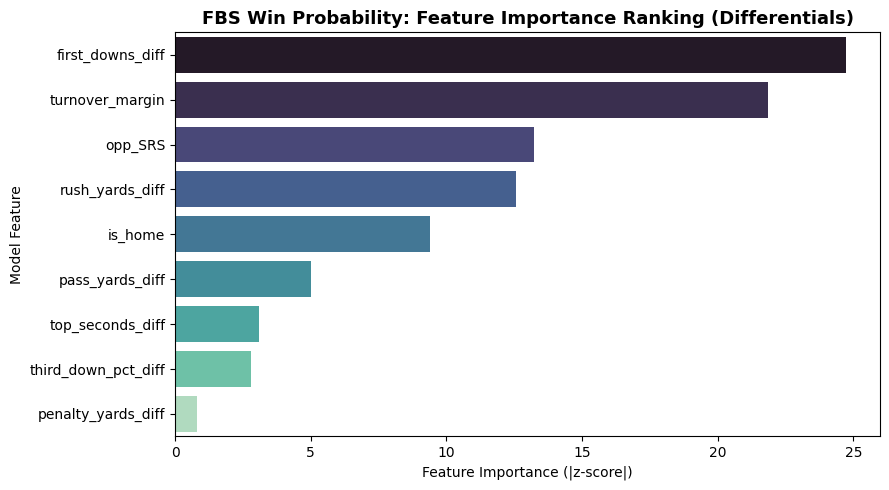

In [298]:
# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=summary_df, x="Importance (|t|)", y="Predictor", palette="mako")
plt.title("FBS Win Probability: Feature Importance Ranking (Differentials)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (|z-score|)")
plt.ylabel("Model Feature")
plt.tight_layout()
plt.show()

Changed the y test here because it is numerical and using class is boolean.

In [299]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [300]:
from scipy.special import expit

In [301]:
pred_probs_diff = ols_model_diff.predict(X_test_sm)

# convert them back to probabilites
p_pred = expit(pred_probs_diff)
y_test = expit(y_test)

metrics_diff = pd.DataFrame({
    "Metric": ["R2", "MSE", "RMSE", "MAE"],
    "Test Score": [
        r2_score(y_test, p_pred),
        mean_squared_error(y_test, p_pred),
        root_mean_squared_error(y_test, p_pred),
        mean_absolute_error(y_test, p_pred)
    ]
})

print("Out-of-Sample Performance (Differentials Model):")
print(metrics_diff.to_string(index=False))

Out-of-Sample Performance (Differentials Model):
Metric  Test Score
    R2    0.608948
   MSE    0.044734
  RMSE    0.211503
   MAE    0.160094


## Here is where I get my overall top and bottom 10 teams for each season in the dataset.

Now do it for whole data set.

In [302]:
X_diff = cfb_diff[diff_predictors]
y_diff = cfb_diff["avg_pos_team_wp"]

# convert the target to log odds for regression
y_diff = np.log(y_diff / (1 - y_diff))

diff_indices = X_diff.index
diff_seasons = cfb_diff.loc[diff_indices, "season"]

# Standardizing features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_diff), columns=diff_predictors, index=X_diff.index)

# Add constant for statsmodels Logit
X_sm = sm.add_constant(X_scaled, has_constant='add')

In [303]:
# Fit ols Regression Model
ols_model_diff = sm.OLS(y_diff, X_sm).fit(disp=False)

conf_int = ols_model_diff.conf_int()
# Feature Importance Summary Table
summary_df = pd.DataFrame({
    "Predictor": ols_model_diff.params.index,
    "Coef": ols_model_diff.params.values,
    "std_err": ols_model_diff.bse.values,
    "t": ols_model_diff.tvalues.values,
    "P>|t|": ols_model_diff.pvalues.values,
    "[0.025": conf_int[0].values,
    "0.975]": conf_int[1].values,
})
summary_df = summary_df[summary_df["Predictor"] != "const"].copy()
summary_df["Importance (|t|)"] = summary_df["t"].abs()
summary_df = summary_df.sort_values(by="Importance (|t|)", ascending=False)

print(summary_df.to_string(index=False))

          Predictor      Coef  std_err          t         P>|t|    [0.025    0.975]  Importance (|t|)
   first_downs_diff  0.958141 0.034406  27.848273 4.681397e-151  0.890678  1.025604         27.848273
    turnover_margin  0.628647 0.026346  23.860882 8.202510e-115  0.576987  0.680307         23.860882
            opp_SRS -0.397662 0.026902 -14.781639  1.102155e-47 -0.450412 -0.344911         14.781639
    rush_yards_diff  0.414890 0.028855  14.378614  2.673063e-45  0.358312  0.471469         14.378614
            is_home  0.311080 0.026305  11.825837  1.565396e-31  0.259501  0.362659         11.825837
    pass_yards_diff -0.173252 0.026101  -6.637646  3.805652e-11 -0.224432 -0.122072          6.637646
   top_seconds_diff  0.094218 0.026076   3.613196  3.077092e-04  0.043088  0.145348          3.613196
third_down_pct_diff  0.087371 0.031125   2.807084  5.033435e-03  0.026341  0.148401          2.807084
 penalty_yards_diff  0.010672 0.026058   0.409534  6.821784e-01 -0.040423  0.06176

In [304]:
# store model predictions in the variable 'predictions'
predictions = ols_model_diff.predict(X_sm)

# convert them back to probabilites
predictions = expit(predictions)
y_diff = expit(y_diff)

metrics_diff = pd.DataFrame({
    "Metric": ["R2", "MSE", "RMSE", "MAE"],
    "Test Score": [
        r2_score(y_diff, predictions),
        mean_squared_error(y_diff, predictions),
        root_mean_squared_error(y_diff, predictions),
        mean_absolute_error(y_diff, predictions)
    ]
})

print("Final performance on dataset (Differentials Model):")
print(metrics_diff.to_string(index=False))

Final performance on dataset (Differentials Model):
Metric  Test Score
    R2    0.579839
   MSE    0.045510
  RMSE    0.213332
   MAE    0.159202


In [305]:
# make new diff and add predictions to it
cfb_diff_results = cfb_diff.copy()
cfb_diff_results['pos_team_predictions'] = predictions
cfb_diff_results['def_pos_team_predictions'] = 1 - predictions

In [306]:
# Perspective 1: team as the offense (pos_team)
pos_perspective = cfb_diff_results[['pos_team', 'season', 'pos_team_predictions']].rename(
    columns={'pos_team': 'team', 'pos_team_predictions': 'prediction'}
)

# Perspective 2: team as the defense (def_pos_team)
def_perspective = cfb_diff_results[['def_pos_team', 'season', 'def_pos_team_predictions']].rename(
    columns={'def_pos_team': 'team', 'def_pos_team_predictions': 'prediction'}
)

# Stack them together so each team's games (offense or defense) are unified
team_long = pd.concat([pos_perspective, def_perspective], ignore_index=True)

# Now aggregate by team, regardless of which side they were on
team_agg = team_long.groupby(['team', 'season'])['prediction'].agg('mean').reset_index()

With the predictions, lets go ahead and make the lists of top 10 and bottom 10 in terms of average win probability

In [307]:
# get top 10 teams by adjusted game control for each season
for yr in sorted(team_agg['season'].unique()):
    top_10 = (
        team_agg[team_agg['season'] == yr]
        .sort_values(by='prediction', ascending=False).head(10)
        .reset_index(drop=True)
    )
    top_10['Rank'] = top_10.index + 1
    
    top_10 = top_10[['Rank', 'season', 'team', 'prediction']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'prediction': 'Average Win Probability'
    })
    
    display(Markdown(f"### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: {yr}"))
    display(Markdown(top_10.to_markdown(index=False)))

### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: 2021

|   Rank |   season | Team             |   Average Win Probability |
|-------:|---------:|:-----------------|--------------------------:|
|      1 |     2021 | Georgia          |                  0.869825 |
|      2 |     2021 | Michigan         |                  0.78659  |
|      3 |     2021 | Coastal Carolina |                  0.786564 |
|      4 |     2021 | UTSA             |                  0.767509 |
|      5 |     2021 | Ohio State       |                  0.767266 |
|      6 |     2021 | Alabama          |                  0.766198 |
|      7 |     2021 | Houston          |                  0.754694 |
|      8 |     2021 | Notre Dame       |                  0.742656 |
|      9 |     2021 | Toledo           |                  0.720715 |
|     10 |     2021 | UCLA             |                  0.69757  |

### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: 2022

|   Rank |   season | Team           |   Average Win Probability |
|-------:|---------:|:---------------|--------------------------:|
|      1 |     2022 | Georgia        |                  0.920638 |
|      2 |     2022 | James Madison  |                  0.836259 |
|      3 |     2022 | Illinois       |                  0.820253 |
|      4 |     2022 | Michigan       |                  0.77809  |
|      5 |     2022 | Ohio State     |                  0.756879 |
|      6 |     2022 | Air Force      |                  0.749042 |
|      7 |     2022 | USC            |                  0.747906 |
|      8 |     2022 | Iowa           |                  0.745195 |
|      9 |     2022 | San José State |                  0.724965 |
|     10 |     2022 | Utah           |                  0.712508 |

### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: 2023

|   Rank |   season | Team         |   Average Win Probability |
|-------:|---------:|:-------------|--------------------------:|
|      1 |     2023 | Georgia      |                  0.856396 |
|      2 |     2023 | Michigan     |                  0.837424 |
|      3 |     2023 | Oregon       |                  0.809388 |
|      4 |     2023 | Ohio State   |                  0.784497 |
|      5 |     2023 | Notre Dame   |                  0.777672 |
|      6 |     2023 | LSU          |                  0.772844 |
|      7 |     2023 | Liberty      |                  0.766363 |
|      8 |     2023 | Kansas State |                  0.758695 |
|      9 |     2023 | Penn State   |                  0.749769 |
|     10 |     2023 | Texas        |                  0.721312 |

### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: 2024

|   Rank |   season | Team          |   Average Win Probability |
|-------:|---------:|:--------------|--------------------------:|
|      1 |     2024 | Penn State    |                  0.772192 |
|      2 |     2024 | Boise State   |                  0.772153 |
|      3 |     2024 | Miami         |                  0.73963  |
|      4 |     2024 | Texas A&M     |                  0.732295 |
|      5 |     2024 | BYU           |                  0.729314 |
|      6 |     2024 | SMU           |                  0.725713 |
|      7 |     2024 | James Madison |                  0.725576 |
|      8 |     2024 | Notre Dame    |                  0.704383 |
|      9 |     2024 | Ole Miss      |                  0.703984 |
|     10 |     2024 | Marshall      |                  0.698921 |

### Top 10 Teams by Opponent-Adjusted Average Win probability for Season: 2025

|   Rank |   season | Team          |   Average Win Probability |
|-------:|---------:|:--------------|--------------------------:|
|      1 |     2025 | Notre Dame    |                  0.848448 |
|      2 |     2025 | James Madison |                  0.800362 |
|      3 |     2025 | Texas Tech    |                  0.781124 |
|      4 |     2025 | Marshall      |                  0.761533 |
|      5 |     2025 | Ohio State    |                  0.754622 |
|      6 |     2025 | Indiana       |                  0.754241 |
|      7 |     2025 | Utah          |                  0.737506 |
|      8 |     2025 | Washington    |                  0.730361 |
|      9 |     2025 | Virginia      |                  0.725062 |
|     10 |     2025 | Oregon        |                  0.722032 |

In [308]:
# get top 10 teams by adjusted game control for each season
for yr in sorted(team_agg['season'].unique()):
    bottom_10 = (
        team_agg[team_agg['season'] == yr]
        .sort_values(by='prediction', ascending=True).head(10)
        .reset_index(drop=True)
    )
    bottom_10['Rank'] = bottom_10.index + 1
    
    bottom_10 = bottom_10[['Rank', 'season', 'team', 'prediction']].rename(columns={
        'season': 'season',
        'team': 'Team',
        'prediction': 'Average Win Probability'
    })
    
    display(Markdown(f"### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: {yr}"))
    display(Markdown(bottom_10.to_markdown(index=False)))

### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: 2021

|   Rank |   season | Team                  |   Average Win Probability |
|-------:|---------:|:----------------------|--------------------------:|
|      1 |     2021 | Delaware              |                 0.0617276 |
|      2 |     2021 | Texas State           |                 0.0942081 |
|      3 |     2021 | Southern Miss         |                 0.165954  |
|      4 |     2021 | Northwestern          |                 0.168795  |
|      5 |     2021 | Massachusetts         |                 0.184647  |
|      6 |     2021 | UConn                 |                 0.185097  |
|      7 |     2021 | Florida International |                 0.210811  |
|      8 |     2021 | Texas Tech            |                 0.227911  |
|      9 |     2021 | Georgia Southern      |                 0.23533   |
|     10 |     2021 | UNLV                  |                 0.23804   |

### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: 2022

|   Rank |   season | Team               |   Average Win Probability |
|-------:|---------:|:-------------------|--------------------------:|
|      1 |     2022 | Kennesaw State     |                0.00760256 |
|      2 |     2022 | Jacksonville State |                0.0938782  |
|      3 |     2022 | Colorado           |                0.122535   |
|      4 |     2022 | South Florida      |                0.150715   |
|      5 |     2022 | Arizona State      |                0.202121   |
|      6 |     2022 | Nebraska           |                0.214793   |
|      7 |     2022 | Vanderbilt         |                0.225699   |
|      8 |     2022 | Boston College     |                0.234099   |
|      9 |     2022 | UL Monroe          |                0.244973   |
|     10 |     2022 | Northwestern       |                0.249861   |

### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: 2023

|   Rank |   season | Team                  |   Average Win Probability |
|-------:|---------:|:----------------------|--------------------------:|
|      1 |     2023 | Delaware              |                0.00547922 |
|      2 |     2023 | Missouri State        |                0.0231669  |
|      3 |     2023 | Kent State            |                0.178932   |
|      4 |     2023 | Arizona State         |                0.22244    |
|      5 |     2023 | Temple                |                0.230679   |
|      6 |     2023 | Vanderbilt            |                0.243003   |
|      7 |     2023 | Florida International |                0.25091    |
|      8 |     2023 | Nevada                |                0.257617   |
|      9 |     2023 | Stanford              |                0.261748   |
|     10 |     2023 | UTEP                  |                0.264529   |

### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: 2024

|   Rank |   season | Team             |   Average Win Probability |
|-------:|---------:|:-----------------|--------------------------:|
|      1 |     2024 | Kent State       |                 0.0578121 |
|      2 |     2024 | Kennesaw State   |                 0.0876395 |
|      3 |     2024 | Purdue           |                 0.0986842 |
|      4 |     2024 | Southern Miss    |                 0.15834   |
|      5 |     2024 | New Mexico State |                 0.217636  |
|      6 |     2024 | Florida State    |                 0.227362  |
|      7 |     2024 | Northwestern     |                 0.230023  |
|      8 |     2024 | Massachusetts    |                 0.23013   |
|      9 |     2024 | UL Monroe        |                 0.23151   |
|     10 |     2024 | Wake Forest      |                 0.233756  |

### Bottom 10 Teams by Opponent-Adjusted Average Win probability for Season: 2025

|   Rank |   season | Team             |   Average Win Probability |
|-------:|---------:|:-----------------|--------------------------:|
|      1 |     2025 | Charlotte        |                  0.156074 |
|      2 |     2025 | Syracuse         |                  0.183163 |
|      3 |     2025 | Massachusetts    |                  0.194018 |
|      4 |     2025 | Georgia State    |                  0.210417 |
|      5 |     2025 | Nevada           |                  0.222015 |
|      6 |     2025 | Oklahoma State   |                  0.225132 |
|      7 |     2025 | Sam Houston      |                  0.244282 |
|      8 |     2025 | Georgia Southern |                  0.261686 |
|      9 |     2025 | UCLA             |                  0.282334 |
|     10 |     2025 | Colorado         |                  0.282502 |

## Repeatability Section for Average Win Probability model

In [309]:
import itertools

diff_predictors = [
    'is_home',
    'turnover_margin',
    'pass_yards_diff',
    'rush_yards_diff',
    'first_downs_diff',
    'third_down_pct_diff',
    'penalty_yards_diff',
    'top_seconds_diff',
    'opp_SRS'
]

seasons = sorted(cfb_diff['season'].unique())

# Pre-aggregate each predictor to a single team-level mean per season, once,
# rather than re-aggregating inside every pairwise loop
season_team_means = (
    cfb_diff.groupby(['season', 'pos_team'])[diff_predictors]
    .mean()
    .reset_index()
)

pair_tables = {}     # (year_a, year_b) -> correlation_results DataFrame
pair_gt_tables = {}  # (year_a, year_b) -> GT object

for year_a, year_b in itertools.combinations(seasons, 2):
    a_panel = (
        season_team_means[season_team_means['season'] == year_a]
        .set_index('pos_team')[diff_predictors]
        .add_suffix('_A')
    )
    b_panel = (
        season_team_means[season_team_means['season'] == year_b]
        .set_index('pos_team')[diff_predictors]
        .add_suffix('_B')
    )

    pair_panel = a_panel.join(b_panel, how='inner').reset_index()

    corr_rows = []
    for name in diff_predictors:
        col_a, col_b = f"{name}_A", f"{name}_B"
        valid = pair_panel[[col_a, col_b]].dropna()

        if len(valid) < 3 or valid[col_a].nunique() < 2 or valid[col_b].nunique() < 2:
            r, p_val = np.nan, np.nan
        else:
            r, p_val = stats.pearsonr(valid[col_a], valid[col_b])

        corr_rows.append({
            'predictor': name,
            'n_teams': len(valid),
            'r': r,
            'p_value': p_val,
            'r_squared': r ** 2 if pd.notnull(r) else np.nan
        })

    pair_results = pd.DataFrame(corr_rows).sort_values(by='r', ascending=False)
    pair_tables[(year_a, year_b)] = pair_results

    gt_table = (
        GT(pair_results)
        .tab_header(
            title=f"{year_a} vs {year_b} Predictor Reliability",
            subtitle="Pearson Correlation (r) between team-level predictor means"
        )
        .cols_label(
            predictor="Predictor",
            n_teams="N Teams",
            r="Pearson r",
            p_value="p-value",
            r_squared="R²"
        )
        .fmt_number(columns=["r", "p_value", "r_squared"], decimals=3)
    )
    pair_gt_tables[(year_a, year_b)] = gt_table

# Display every pairwise table
for (year_a, year_b), gt_table in pair_gt_tables.items():
    display(gt_table)

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
4     first_downs_diff      122  0.402949  0.000004   0.162368
8              opp_SRS      122  0.340895  0.000122   0.116210
3      rush_yards_diff      122  0.317286  0.000370   0.100670
2      pass_yards_diff      122  0.201402  0.026115   0.040563
5  third_down_pct_diff      122  0.082336  0.367269   0.006779
1      turnover_margin      122  0.072051  0.430313   0.005191
7     top_seconds_diff      122  0.051645  0.572110   0.002667
6   penalty_yards_diff      122  0.031858  0.727576   0.001015
0              is_home      122 -0.029216  0.749390   0.000854, _body=<great_tables._gt_data.Body object at 0x000002177BE0A9F0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D71FB30>, _spanners=Spanners([]), _heading=Heading(title='2021 vs 2022 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C71C3E0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C71CC20>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C751EB0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000021729A510D0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
8              opp_SRS      124  0.364096  0.000032   0.132566
4     first_downs_diff      124  0.298236  0.000767   0.088945
3      rush_yards_diff      124  0.280585  0.001597   0.078728
5  third_down_pct_diff      124  0.252847  0.004608   0.063932
6   penalty_yards_diff      124  0.141366  0.117320   0.019984
0              is_home      124  0.044277  0.625345   0.001960
2      pass_yards_diff      124  0.040487  0.655266   0.001639
7     top_seconds_diff      124  0.019465  0.830096   0.000379
1      turnover_margin      124 -0.024915  0.783569   0.000621, _body=<great_tables._gt_data.Body object at 0x000002172C6DBFE0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000021738086300>, _spanners=Spanners([]), _heading=Heading(title='2021 vs 2023 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6DA840>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6DA300>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6D8FB0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6DA6F0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
8              opp_SRS      123  0.419690  0.000001   0.176140
3      rush_yards_diff      123  0.214718  0.017083   0.046104
5  third_down_pct_diff      123  0.130440  0.150425   0.017015
6   penalty_yards_diff      123  0.111149  0.220986   0.012354
4     first_downs_diff      123  0.088921  0.328049   0.007907
0              is_home      123  0.085260  0.348431   0.007269
7     top_seconds_diff      123  0.076726  0.398953   0.005887
1      turnover_margin      123  0.044805  0.622659   0.002007
2      pass_yards_diff      123 -0.208968  0.020364   0.043668, _body=<great_tables._gt_data.Body object at 0x000002172C6DA060>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000021729579940>, _spanners=Spanners([]), _heading=Heading(title='2021 vs 2024 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6D9250>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6D9E80>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6DA600>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6D90D0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
8              opp_SRS      124  0.410266  0.000002   0.168318
4     first_downs_diff      124  0.247935  0.005496   0.061472
5  third_down_pct_diff      124  0.138905  0.123905   0.019295
6   penalty_yards_diff      124  0.122612  0.174894   0.015034
7     top_seconds_diff      124  0.088147  0.330293   0.007770
3      rush_yards_diff      124  0.026061  0.773871   0.000679
0              is_home      124  0.024924  0.783487   0.000621
1      turnover_margin      124 -0.050884  0.574631   0.002589
2      pass_yards_diff      124 -0.086870  0.337375   0.007546, _body=<great_tables._gt_data.Body object at 0x000002172C6D51F0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D6D5790>, _spanners=Spanners([]), _heading=Heading(title='2021 vs 2025 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6D51C0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6D79B0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6D4860>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6D6A20>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=             predictor  n_teams         r       p_value  r_squared
8              opp_SRS      128  0.532921  9.448999e-11   0.284005
4     first_downs_diff      128  0.286333  1.050686e-03   0.081986
3      rush_yards_diff      128  0.280551  1.338417e-03   0.078709
5  third_down_pct_diff      128  0.133456  1.331499e-01   0.017810
6   penalty_yards_diff      128  0.110814  2.130358e-01   0.012280
2      pass_yards_diff      128  0.060711  4.960274e-01   0.003686
7     top_seconds_diff      128  0.030622  7.314989e-01   0.000938
1      turnover_margin      128  0.021356  8.108934e-01   0.000456
0              is_home      128 -0.019080  8.307273e-01   0.000364, _body=<great_tables._gt_data.Body object at 0x000002172C6D44A0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172957A300>, _spanners=Spanners([]), _heading=Heading(title='2022 vs 2023 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6D4F50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6D7E00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6D73B0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C71ED80>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), tabl

GT(_tbl_data=             predictor  n_teams         r       p_value  r_squared
8              opp_SRS      126  0.475819  1.793617e-08   0.226404
5  third_down_pct_diff      126  0.163000  6.820448e-02   0.026569
4     first_downs_diff      126  0.148315  9.743367e-02   0.021997
7     top_seconds_diff      126  0.145422  1.042187e-01   0.021148
3      rush_yards_diff      126  0.142282  1.119947e-01   0.020244
1      turnover_margin      126  0.134905  1.320406e-01   0.018199
6   penalty_yards_diff      126  0.078472  3.824360e-01   0.006158
2      pass_yards_diff      126 -0.056028  5.331963e-01   0.003139
0              is_home      126 -0.085311  3.422148e-01   0.007278, _body=<great_tables._gt_data.Body object at 0x000002172C6D9010>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172C6DC380>, _spanners=Spanners([]), _heading=Heading(title='2022 vs 2024 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C69E420>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C69E540>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C71E900>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6D9730>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), tabl

GT(_tbl_data=             predictor  n_teams         r       p_value  r_squared
8              opp_SRS      129  0.547698  1.853118e-11   0.299973
7     top_seconds_diff      129  0.188334  3.256443e-02   0.035470
4     first_downs_diff      129  0.182816  3.810840e-02   0.033422
5  third_down_pct_diff      129  0.149236  9.141805e-02   0.022271
3      rush_yards_diff      129  0.114818  1.950862e-01   0.013183
0              is_home      129 -0.008414  9.246031e-01   0.000071
2      pass_yards_diff      129 -0.018142  8.382987e-01   0.000329
1      turnover_margin      129 -0.072138  4.165569e-01   0.005204
6   penalty_yards_diff      129 -0.130094  1.417102e-01   0.016924, _body=<great_tables._gt_data.Body object at 0x000002172C6D74D0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172D6C4E00>, _spanners=Spanners([]), _heading=Heading(title='2022 vs 2025 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6D72F0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6D6480>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6D6810>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6D46E0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), tabl

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
8              opp_SRS      128  0.355269  0.000039   0.126216
4     first_downs_diff      128  0.225582  0.010460   0.050887
3      rush_yards_diff      128  0.142099  0.109593   0.020192
5  third_down_pct_diff      128  0.116726  0.189474   0.013625
1      turnover_margin      128  0.073619  0.408886   0.005420
6   penalty_yards_diff      128  0.058846  0.509377   0.003463
0              is_home      128  0.053515  0.548543   0.002864
7     top_seconds_diff      128 -0.112367  0.206653   0.012626
2      pass_yards_diff      128 -0.128327  0.148855   0.016468, _body=<great_tables._gt_data.Body object at 0x000002172C6D8CE0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172C71C680>, _spanners=Spanners([]), _heading=Heading(title='2023 vs 2024 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6D4470>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C6D65A0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C6D47D0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172D6CBAD0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

GT(_tbl_data=             predictor  n_teams         r       p_value  r_squared
8              opp_SRS      131  0.413171  9.362533e-07   0.170710
3      rush_yards_diff      131  0.310462  3.074454e-04   0.096387
4     first_downs_diff      131  0.270281  1.795187e-03   0.073052
5  third_down_pct_diff      131  0.084386  3.379152e-01   0.007121
6   penalty_yards_diff      131  0.067553  4.432895e-01   0.004563
7     top_seconds_diff      131  0.031901  7.175608e-01   0.001018
1      turnover_margin      131  0.028336  7.479999e-01   0.000803
0              is_home      131  0.020346  8.175794e-01   0.000414
2      pass_yards_diff      131 -0.028488  7.466969e-01   0.000812, _body=<great_tables._gt_data.Body object at 0x000002172C699C10>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000217766178F0>, _spanners=Spanners([]), _heading=Heading(title='2023 vs 2025 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C6993D0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C699FD0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C69BD70>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C6D80B0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), tabl

GT(_tbl_data=             predictor  n_teams         r   p_value  r_squared
8              opp_SRS      129  0.407658  0.000002   0.166185
3      rush_yards_diff      129  0.155643  0.078186   0.024225
4     first_downs_diff      129  0.141549  0.109574   0.020036
5  third_down_pct_diff      129  0.123395  0.163565   0.015226
7     top_seconds_diff      129  0.109590  0.216340   0.012010
1      turnover_margin      129  0.036194  0.683852   0.001310
2      pass_yards_diff      129 -0.003285  0.970526   0.000011
0              is_home      129 -0.040856  0.645726   0.001669
6   penalty_yards_diff      129 -0.052819  0.552186   0.002790, _body=<great_tables._gt_data.Body object at 0x000002172C69BAA0>, _boxhead=Boxhead([ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n_teams', type=<ColInfoTypeEnum.default: 1>, column_label='N Teams', column_align='right', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002172C69C470>, _spanners=Spanners([]), _heading=Heading(title='2024 vs 2025 Predictor Reliability', subtitle='Pearson Correlation (r) between team-level predictor means', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002172C69B200>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002172C698260>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002172C69BCB0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000002172C69BF20>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr


The split season reliabilty for this model is quite bad across seasons. This model may be a lot more concerning than I had intially imagined.

---

# **Question 1.)** 


**Student answer:** I have listed the top 10 and bottom 10 teams for each season according to each model in their respective sections.

---

# **Question 2.)** 

### Assess which of the models has the best predictive out of sample performance by splitting each season into train and test sets.  Explain why your choice of split(s) is appropriate.

**Student answer:** The model with the best out of sample performance is probably my Average win probability model. All of the models perform quite poorly with out of sample data but I feel the best about my average win probability because it has a slighlty lower rmse within its range when compared to the other models. I split the SRS model into half seasons for the test and train datasets because SRS of a season should stay within the scope of a season as schedules, coaches, and roster change year to year. Next, I performed the same test and train splits on my average game control model for similar reasons as my SRS model but I also thought it would interesting to see the changes in game control from one half of a season to another. Lastly, I split the average win probability model by season. The reason for doing so is to examine how win probability (using the same predictors) changes from season to season. There are lots of things that change throughout a season and for how that model is constructed, I thought it was best to address it on a season to season basis.

---

# **Question 3.)** 

### Assess which of the models has the best repeatbility by splitting each season into train and test sets.  Explain why your choice of split(s) is appropriate.

I believe that SRS model has the best repeatability as it seems to be more consistent across its respective split(s) in terms of R, unlike the average win probability model where its predictors are quite inconsistent. I chose to split both the SRS and the oponent-adjusted game control models up by half seasons and make a table for each season in that dataset. I did this split for both the SRS model and the game control model to abide by my rationale in question 2. The SRS and game control models should be examined within the scope of the same season due to how their models are calculated. Lastly, I chose to split the average win probability model up by seasons. Essentially comparing the seasons across every single combination possible of seasons in the data. Essentially going through every cartesian product such that 2021 gets compred to 2022, then to 2023, etc. I do this since each season should be treated as a whole (due to how to model is made) and comparing their results across seasons would stay consistent with my work for question 2. 